#### Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv")
data.head()

,created_date,account_name,campaign_objective,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent
0,2023-01-01,Client A - Fashion,Traffic,915434.0,81436.0,92554.0,15544.0,0.0,0.0,0.0,0.0,2357742.0
1,2023-01-01,Client A - Fashion,Sales,103328.0,89200.0,22100.0,38038.0,1199.0,817.0,824.0,3353702.0,3578529.0
2,2023-01-01,Client B - Beauty,Traffic,336015.0,141082.0,26321.0,46107.0,0.0,0.0,0.0,0.0,1482711.0
3,2023-01-01,Client B - Beauty,Sales,864410.0,400596.0,10719.0,29397.0,3395.0,960.0,591.0,3470984.0,4335272.0
4,2023-01-01,Client C - Fashion,Traffic,916254.0,319415.0,32995.0,37496.0,0.0,0.0,0.0,0.0,1897353.0


In [ ]:
len(data)

4380

In [ ]:
len(data.columns)

12

In [ ]:
data.describe()

,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent
count,4.380000e+03,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4.380000e+03,4.380000e+03
mean,6.509784e+05,319465.963721,64658.303105,32284.340525,3270.216758,329.622032,299.895434,2.385893e+06,2.957227e+06
std,3.561788e+05,177837.971292,35658.804018,17818.611700,4149.902583,416.383348,401.934926,3.200339e+06,1.858174e+06
min,1.003580e+05,50134.000000,10029.000000,5008.000000,0.000000,0.000000,0.000000,0.000000e+00,1.014850e+05
25%,3.682400e+05,178756.300000,36632.250000,17758.200000,0.000000,0.000000,0.000000,0.000000e+00,1.474532e+06
50%,6.193560e+05,305107.500000,61225.000000,30892.500000,505.000000,50.000000,5.000000,5.176000e+04,2.856742e+06
75%,8.774980e+05,428148.125000,86084.450000,43292.750000,6296.150000,630.000000,560.250000,4.531508e+06,4.153663e+06
max,1.998018e+06,998320.000000,199252.000000,99554.000000,19964.000000,1992.000000,1980.000000,1.590125e+07,9.970642e+06


In [ ]:
data['campaign_objective'].value_counts()

,count
campaign_objective,
Traffic,2190
Sales,2190


The data shown that there are balance campaign count for Traffic and Sales.

In [ ]:
data['account_name'].value_counts()

,count
account_name,
Client A - Fashion,730
Client B - Beauty,730
Client C - Fashion,730
Client D - Beauty,730
Client E - FMCG,730
Client F - FMCG,730


Even for all client, the data is balance.

In [ ]:
data.isnull().sum()

,0
created_date,0
account_name,0
campaign_objective,0
impressions,0
reach,0
clicks,0
link_clicks,0
content_views,0
add_to_cart,0
purchase,0


In [ ]:
data.duplicated().sum()

np.int64(0)

Data is clean, no missing value and duplicate.

#### Feature Engineering

In [ ]:

def feature_engineering(df):
    df['created_date'] = pd.to_datetime(df['created_date'])
    df['month_year'] = df['created_date'].dt.to_period('M')
    df['day_name'] = df['created_date'].dt.day_name()
    df['industry'] = df['account_name'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else 'Unknown')
    df['account_name'] = df['account_name'].str.split(' - ').str[0]
    df['ROAS'] = df['purchase_value'] / (df['amount_spent'] + 0.0001)

In [ ]:
feature_engineering(data)
data.head()

,created_date,account_name,campaign_objective,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent,month_year,day_name,industry,ROAS
0,2023-01-01,Client A,Traffic,915434.0,81436.0,92554.0,15544.0,0.0,0.0,0.0,0.0,2357742.0,2023-01,Sunday,Fashion,0.000000
1,2023-01-01,Client A,Sales,103328.0,89200.0,22100.0,38038.0,1199.0,817.0,824.0,3353702.0,3578529.0,2023-01,Sunday,Fashion,0.937173
2,2023-01-01,Client B,Traffic,336015.0,141082.0,26321.0,46107.0,0.0,0.0,0.0,0.0,1482711.0,2023-01,Sunday,Beauty,0.000000
3,2023-01-01,Client B,Sales,864410.0,400596.0,10719.0,29397.0,3395.0,960.0,591.0,3470984.0,4335272.0,2023-01,Sunday,Beauty,0.800638
4,2023-01-01,Client C,Traffic,916254.0,319415.0,32995.0,37496.0,0.0,0.0,0.0,0.0,1897353.0,2023-01,Sunday,Fashion,0.000000


#### EDA

In [ ]:
data.select_dtypes(include='number').sum()

,0
impressions,2.851285e+09
reach,1.399261e+09
clicks,2.832034e+08
link_clicks,1.414054e+08
content_views,1.432355e+07
add_to_cart,1.443744e+06
purchase,1.313542e+06
purchase_value,1.045021e+10
amount_spent,1.295266e+10
ROAS,7.305825e+03


## A. Performance Metrics Analysis

We well use data to answer
1. Berapa nilai CTR (Click-Through Rate) secara keseluruhan?
2. Bagaimana performa CTR berdasarkan campaign objective (Traffic vs Sales)?
3. Berapa total Purchase Value (Omzet) yang dihasilkan dari iklan?
4. Berapa nilai ROAS (Return on Advertising Spend) secara keseluruhan?

In [ ]:
def calculate_ctr(data):
    total_clicks = data['clicks'].sum()
    total_impressions = data['impressions'].sum()
    ctr = (total_clicks / total_impressions) * 100
    return ctr

### CTR (Click-Through Rate) secara keseluruhan

In [ ]:
# Overall CTR
overall_ctr = calculate_ctr(data)
print(f"Overall CTR: {overall_ctr:.2f}%")

Overall CTR: 9.93%


Nilai CTR keseluruhan adalah 9.93%.

Nilai ini cukup besar, dimana rata-rata iklan yang bagus memiliki CTR sekitar 3-5%.

### CTR berdasarkan campaign objective

In [ ]:
traffic_data = data[data['campaign_objective'] == 'Traffic']
sales_data = data[data['campaign_objective'] == 'Sales']

In [ ]:
traffic_ctr = calculate_ctr(traffic_data)
print(f"CTR for Traffic: {traffic_ctr:.2f}%")

CTR for Traffic: 9.98%


In [ ]:
sales_ctr = calculate_ctr(sales_data)
print(f"CTR for Sales: {sales_ctr:.2f}%")

CTR for Sales: 9.88%


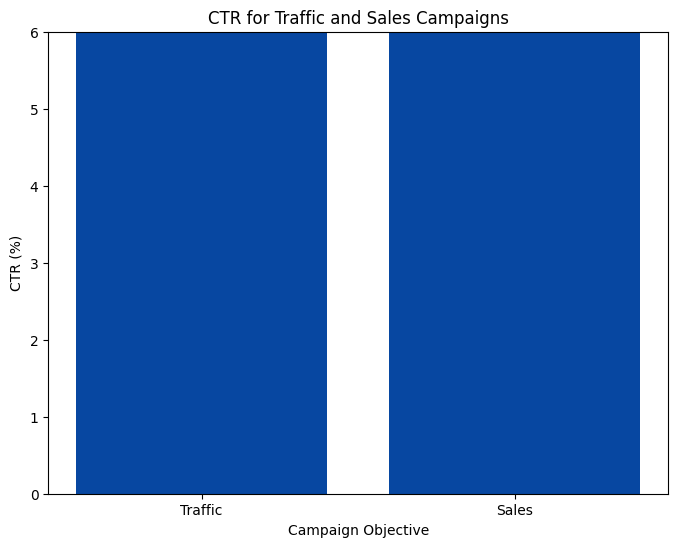

In [ ]:
campaign_types = ['Traffic', 'Sales']
ctr_values = [traffic_ctr, sales_ctr]

fig, ax = plt.subplots(figsize=(8, 6))
bar_container = ax.bar(campaign_types, ctr_values, color=['#0747a1', '#0747a1'])
ax.set(xlabel='Campaign Objective', ylabel='CTR (%)', title='CTR for Traffic and Sales Campaigns', ylim=(0, 6))
ax.bar_label(bar_container, fmt='{:,.2f}')
plt.show()

CTR untuk tipe Traffic sebesar 9.98%, sedangkan untuk Sales sebesar 9.88%.

### Total Purchase Value (Omzet) yang dihasilkan dari iklan

In [ ]:
total_purchase_value = data['purchase_value'].sum()
print(f"Total Omzet: {total_purchase_value:.2f}")

Total Omzet: 10450212835.40


In [ ]:
data.groupby('campaign_objective')['purchase_value'].sum()

,purchase_value
campaign_objective,
Sales,1.045021e+10
Traffic,0.000000e+00


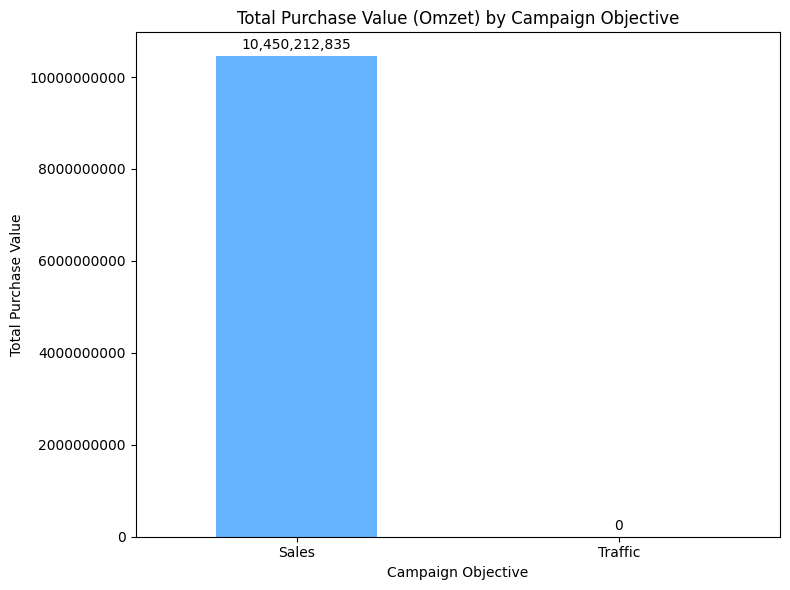

In [ ]:
omzet_by_campaign = data.groupby('campaign_objective')['purchase_value'].sum()

fig, ax = plt.subplots(figsize=(8, 6))
omzet_by_campaign.plot(kind='bar', ax=ax, color=['#66b3ff', '#ff9999'])
ax.set_title('Total Purchase Value (Omzet) by Campaign Objective')
ax.set_xlabel('Campaign Objective')
ax.set_ylabel('Total Purchase Value')
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
data.groupby('industry')['purchase_value'].sum()

,purchase_value
industry,
Beauty,3.502457e+09
FMCG,3.458425e+09
Fashion,3.489331e+09


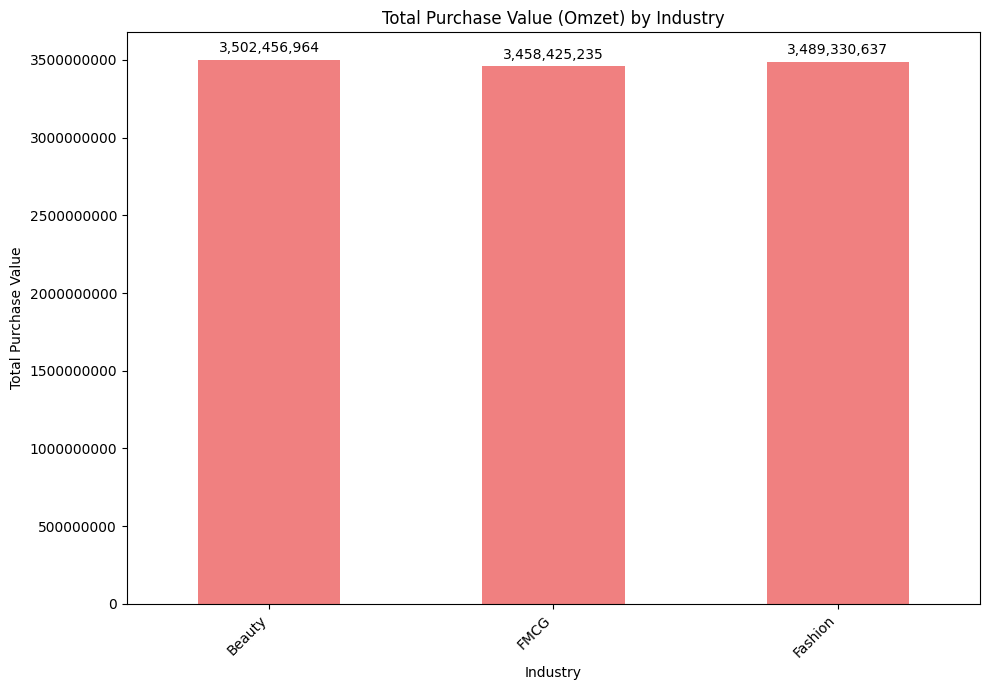

In [ ]:
# Plot omzet by industry
omzet_by_industry = data.groupby('industry')['purchase_value'].sum()

fig, ax = plt.subplots(figsize=(10, 7))
omzet_by_industry.plot(kind='bar', ax=ax, color='lightcoral')
ax.set_title('Total Purchase Value (Omzet) by Industry')
ax.set_xlabel('Industry')
ax.set_ylabel('Total Purchase Value')
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

### ROAS (Return on Advertising Spend) secara keseluruhan

In [ ]:

purchase_value = data['purchase_value'].sum()
total_spent = data['amount_spent'].sum()
roas = (purchase_value / total_spent)
roas

np.float64(0.8068008185729967)

The ROAS is 0.8

## B. Time Series Analysis

###  Tren performa iklan dari waktu ke waktu

In [ ]:
data["CTR"] = data["link_clicks"] / data["impressions"] * 100
data.head()

,created_date,account_name,campaign_objective,impressions,reach,clicks,link_clicks,content_views,add_to_cart,purchase,purchase_value,amount_spent,month_year,day_name,industry,ROAS,CTR
0,2023-01-01,Client A,Traffic,915434.0,81436.0,92554.0,15544.0,0.0,0.0,0.0,0.0,2357742.0,2023-01,Sunday,Fashion,0.000000,1.697992
1,2023-01-01,Client A,Sales,103328.0,89200.0,22100.0,38038.0,1199.0,817.0,824.0,3353702.0,3578529.0,2023-01,Sunday,Fashion,0.937173,36.812868
2,2023-01-01,Client B,Traffic,336015.0,141082.0,26321.0,46107.0,0.0,0.0,0.0,0.0,1482711.0,2023-01,Sunday,Beauty,0.000000,13.721709
3,2023-01-01,Client B,Sales,864410.0,400596.0,10719.0,29397.0,3395.0,960.0,591.0,3470984.0,4335272.0,2023-01,Sunday,Beauty,0.800638,3.400817
4,2023-01-01,Client C,Traffic,916254.0,319415.0,32995.0,37496.0,0.0,0.0,0.0,0.0,1897353.0,2023-01,Sunday,Fashion,0.000000,4.092315


In [ ]:
monthly_ctr = (
    data
    .groupby(["month_year", "campaign_objective"])
    .agg({
        "clicks": "sum",
        "impressions": "sum"
    })
    .reset_index()
)

monthly_ctr["CTR"] = monthly_ctr["clicks"] / monthly_ctr["impressions"] * 100
monthly_ctr["month_year"] = monthly_ctr["month_year"].astype(str)


In [ ]:
ctr_traffic = monthly_ctr[monthly_ctr["campaign_objective"] == "Traffic"]
ctr_sales = monthly_ctr[monthly_ctr["campaign_objective"] == "Sales"]

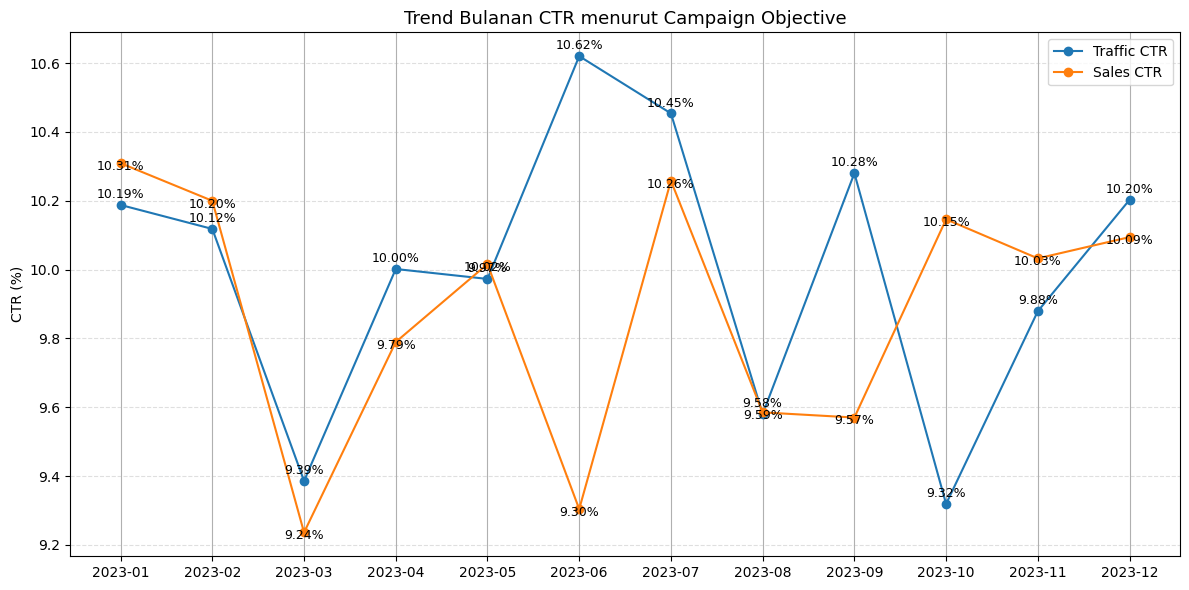

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    ctr_traffic["month_year"],
    ctr_traffic["CTR"],
    marker="o",
    label="Traffic CTR"
)

plt.plot(
    ctr_sales["month_year"],
    ctr_sales["CTR"],
    marker="o",
    label="Sales CTR"
)

for x, y in zip(ctr_traffic["month_year"], ctr_traffic["CTR"]):
    plt.text(x, y + 0.02, f"{y:.2f}%", ha="center", fontsize=9)

for x, y in zip(ctr_sales["month_year"], ctr_sales["CTR"]):
    plt.text(x, y - 0.02, f"{y:.2f}%", ha="center", fontsize=9)

plt.title("Trend Bulanan CTR menurut Campaign Objective", fontsize=13)
plt.ylabel("CTR (%)")

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
df_sales = data.copy()

monthly_roas = (
    df_sales
    .groupby("month_year")
    .agg({
        "purchase_value": "sum",
        "amount_spent": "sum"
    })
    .reset_index()
)

monthly_roas["ROAS"] = (
    monthly_roas["purchase_value"] / monthly_roas["amount_spent"]
)
monthly_roas["month_year"] = monthly_roas["month_year"].astype(str)


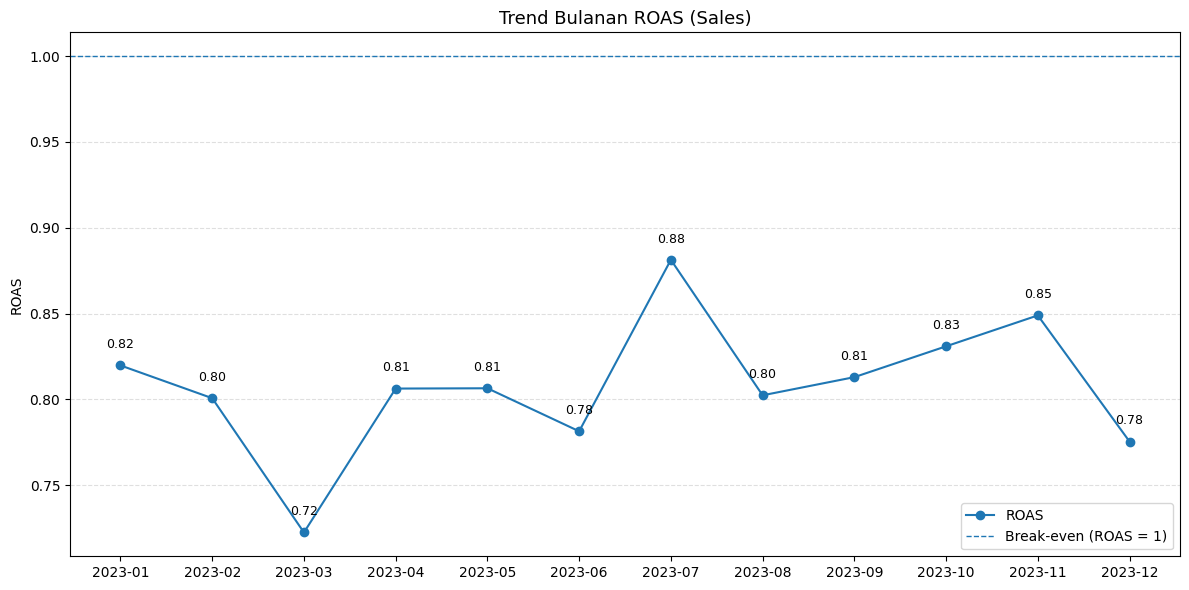

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_roas["month_year"],
    monthly_roas["ROAS"],
    marker="o",
    label="ROAS"
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1,
    label="Break-even (ROAS = 1)"
)

for x, y in zip(monthly_roas["month_year"], monthly_roas["ROAS"]):
    plt.text(
        x,
        y + 0.01,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("Trend Bulanan ROAS (Sales)", fontsize=13)
plt.ylabel("ROAS")

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
monthly_roas = monthly_roas.sort_values("month_year").copy()

monthly_roas["ROAS_change"] = monthly_roas["ROAS"].diff()
monthly_roas["ROAS_change_pct"] = monthly_roas["ROAS"].pct_change()

### Bulan performa iklan mengalami peningkatan signifikan

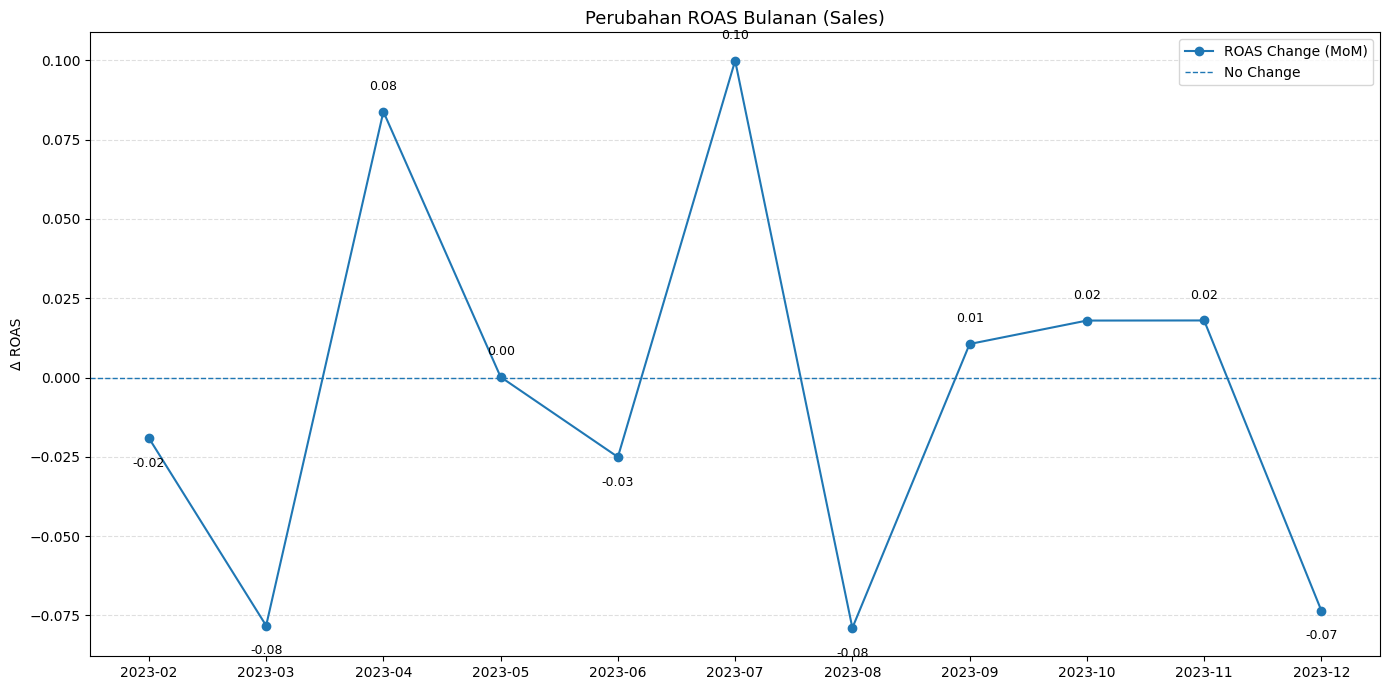

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_roas["month_year"],
    monthly_roas["ROAS_change"],
    marker="o",
    label="ROAS Change (MoM)"
)

plt.axhline(0, linestyle="--", linewidth=1, label="No Change")

for x, y in zip(monthly_roas["month_year"], monthly_roas["ROAS_change"]):
    if pd.notna(y):
        offset = 0.01 if y > 0 else -0.01
        va = "top" if y > 0 else "bottom"

        plt.text(
            x,
            y + offset,
            f"{y:.2f}",
            ha="center",
            va=va,
            fontsize=9
        )

plt.title("Perubahan ROAS Bulanan (Sales)", fontsize=13)
plt.ylabel("Δ ROAS")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Pola musiman

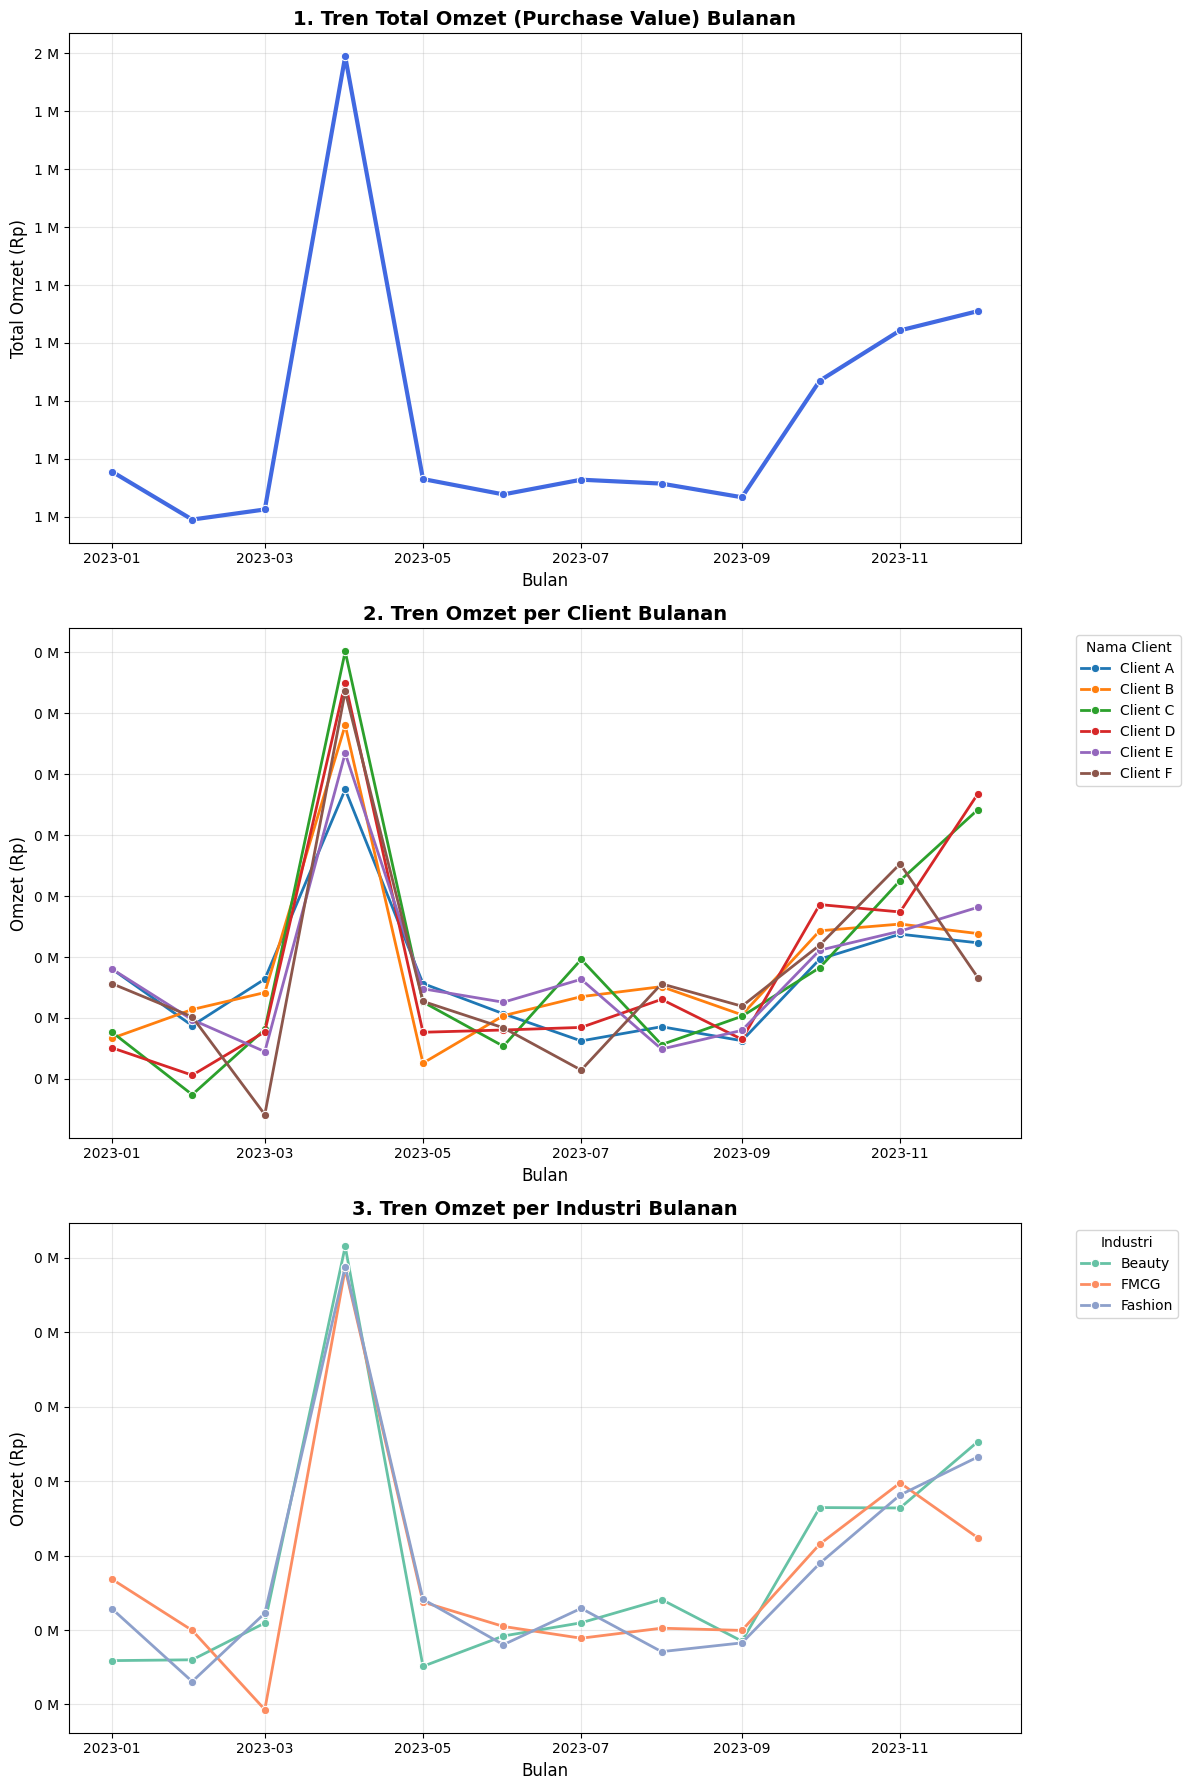

In [ ]:
import seaborn as sns
filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)

df['created_date'] = pd.to_datetime(df['created_date'])
df['industry'] = df['account_name'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else 'Unknown')
df['account_clean'] = df['account_name'].apply(lambda x: x.split(' - ')[0] if ' - ' in x else x)
df['purchase_value'] = pd.to_numeric(df['purchase_value'], errors='coerce').fillna(0)

df['month_dt'] = df['created_date'].dt.to_period('M').dt.start_time
df['month_str'] = df['created_date'].dt.to_period('M').astype(str)

monthly_overall = df.groupby('month_dt')['purchase_value'].sum().reset_index()

monthly_client = df.groupby(['month_dt', 'account_clean'])['purchase_value'].sum().reset_index()

monthly_industry = df.groupby(['month_dt', 'industry'])['purchase_value'].sum().reset_index()
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

sns.lineplot(data=monthly_overall, x='month_dt', y='purchase_value', marker='o', linewidth=3, color='royalblue', ax=axes[0])
axes[0].set_title('1. Tren Total Omzet (Purchase Value) Bulanan', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Omzet (Rp)', fontsize=12)
axes[0].set_xlabel('Bulan', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f} M".format(x/1e9)))

sns.lineplot(data=monthly_client, x='month_dt', y='purchase_value', hue='account_clean', marker='o', linewidth=2, palette='tab10', ax=axes[1])
axes[1].set_title('2. Tren Omzet per Client Bulanan', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Omzet (Rp)', fontsize=12)
axes[1].set_xlabel('Bulan', fontsize=12)
axes[1].legend(title='Nama Client', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f} M".format(x/1e9)))

sns.lineplot(data=monthly_industry, x='month_dt', y='purchase_value', hue='industry', marker='o', linewidth=2, palette='Set2', ax=axes[2])
axes[2].set_title('3. Tren Omzet per Industri Bulanan', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Omzet (Rp)', fontsize=12)
axes[2].set_xlabel('Bulan', fontsize=12)
axes[2].legend(title='Industri', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f} M".format(x/1e9)))

plt.tight_layout()
plt.savefig('monthly_purchase_value_focus.png')
plt.show()

##C. Industry & Account Analysis

### Industri yang memiliki nilai rata-rata omzet tertinggi

/tmp/ipython-input-453593471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


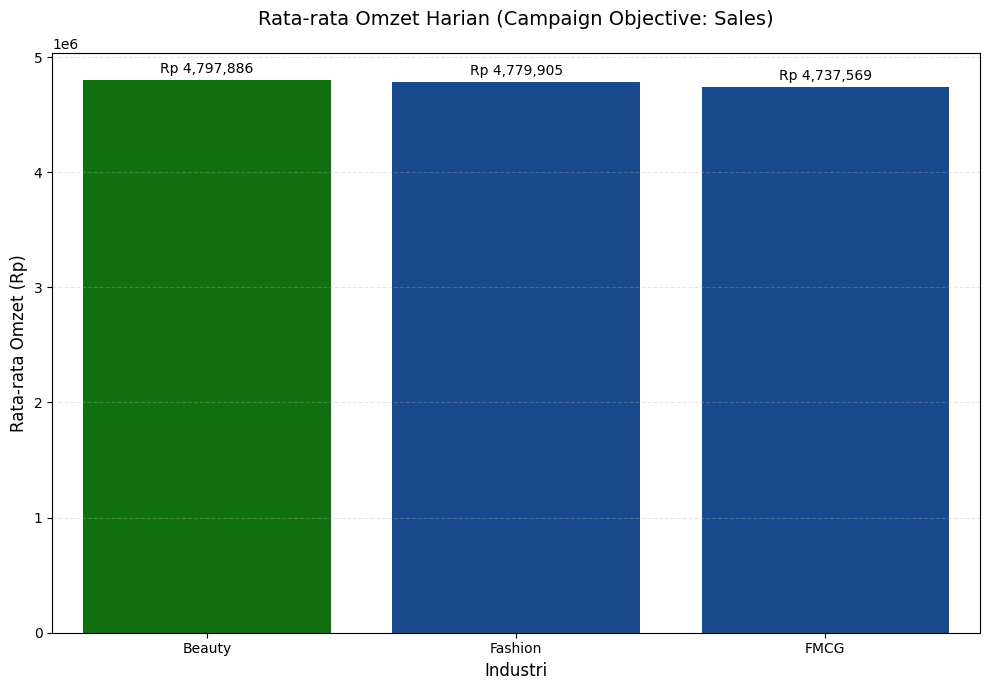

In [ ]:

filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)
df['purchase_value'] = pd.to_numeric(df['purchase_value'], errors='coerce').fillna(0)
df['industry'] = df['account_name'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else 'Unknown')
df_sales = df[df['campaign_objective'] == 'Sales'].copy()
avg_revenue_sales = df_sales.groupby('industry')['purchase_value'].mean().reset_index()
avg_revenue_sales = avg_revenue_sales.sort_values('purchase_value', ascending=False)
plt.rcParams["figure.figsize"] = (10, 7)
colors = ['green'] + ['#0747a1'] * (len(avg_revenue_sales) - 1)

ax = sns.barplot(
    data=avg_revenue_sales,
    x='industry',
    y='purchase_value',
    palette=colors
)
for container in ax.containers:
    labels = [f'Rp {x:,.0f}' for x in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('Rata-rata Omzet Harian (Campaign Objective: Sales)', fontsize=14, pad=20)
plt.xlabel('Industri', fontsize=12)
plt.ylabel('Rata-rata Omzet (Rp)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

### Akun atau brand yang paling efektif menghasilkan revenue

/tmp/ipython-input-4101761878.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=account_revenue, x='purchase_value', y='account_clean', palette=colors)


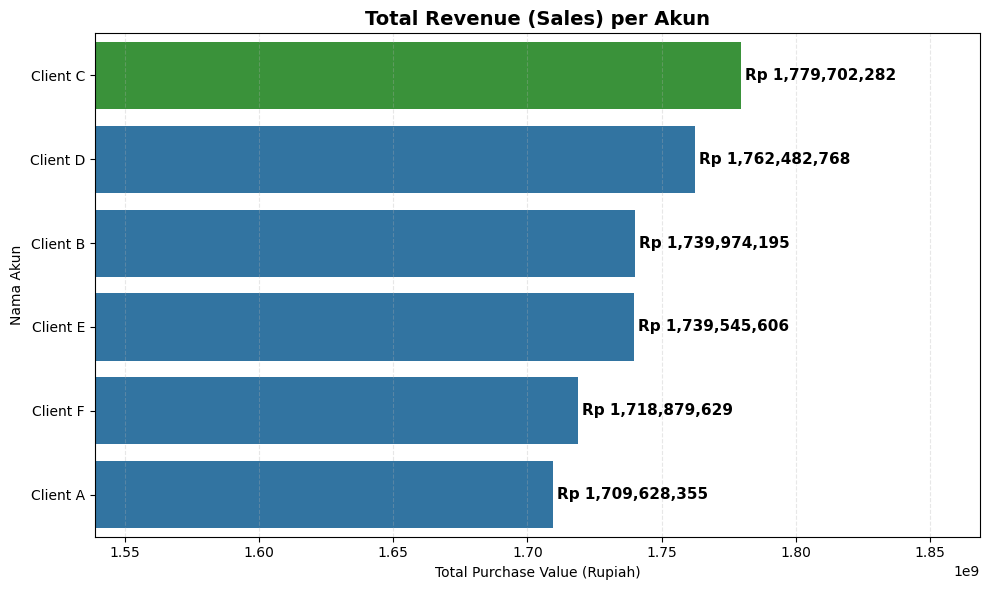

--- Peringkat Akun Berdasarkan Revenue (Sales Only) ---
  account_clean  purchase_value
2      Client C    1.779702e+09
3      Client D    1.762483e+09
1      Client B    1.739974e+09
4      Client E    1.739546e+09
5      Client F    1.718880e+09
0      Client A    1.709628e+09


In [ ]:

filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)
df['purchase_value'] = pd.to_numeric(df['purchase_value'], errors='coerce').fillna(0)
df['account_clean'] = df['account_name'].apply(lambda x: x.split(' - ')[0] if ' - ' in x else x)

df_sales = df[df['campaign_objective'] == 'Sales'].copy()

account_revenue = df_sales.groupby('account_clean')['purchase_value'].sum().reset_index()
account_revenue = account_revenue.sort_values('purchase_value', ascending=False)

plt.figure(figsize=(10, 6))

top_account = account_revenue.iloc[0]['account_clean']
colors = ['#2ca02c' if x == top_account else '#1f77b4' for x in account_revenue['account_clean']]

ax = sns.barplot(data=account_revenue, x='purchase_value', y='account_clean', palette=colors)

for container in ax.containers:
    labels = [f'Rp {x:,.0f}' for x in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontweight='bold', fontsize=11)

plt.title('Total Revenue (Sales) per Akun', fontsize=14, fontweight='bold')
plt.xlabel('Total Purchase Value (Rupiah)')
plt.ylabel('Nama Akun')
plt.grid(axis='x', linestyle='--', alpha=0.3)

min_val = account_revenue['purchase_value'].min() * 0.9
plt.xlim(left=min_val)

plt.tight_layout()
plt.savefig('top_account_revenue_sales_only.png')
plt.show()

print("--- Peringkat Akun Berdasarkan Revenue (Sales Only) ---")
print(account_revenue)

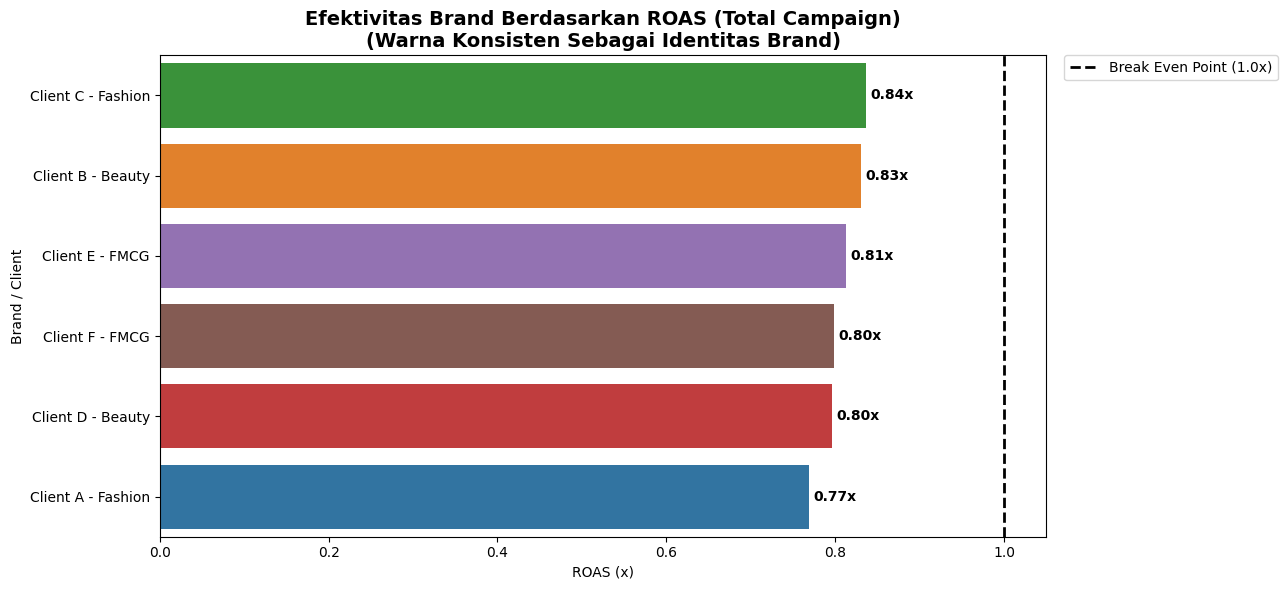

      account_name  amount_spent  purchase_value  ROAS
Client C - Fashion 2,127,994,359   1,779,702,282 0.84x
 Client B - Beauty 2,094,255,354   1,739,974,195 0.83x
   Client E - FMCG 2,140,262,638   1,739,545,606 0.81x
   Client F - FMCG 2,152,087,172   1,718,879,629 0.80x
 Client D - Beauty 2,214,682,883   1,762,482,768 0.80x
Client A - Fashion 2,223,372,815   1,709,628,355 0.77x


In [ ]:

df = pd.read_csv('Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv')

df['purchase_value'] = pd.to_numeric(df['purchase_value'], errors='coerce').fillna(0)
df['amount_spent'] = pd.to_numeric(df['amount_spent'], errors='coerce').fillna(0)

brand_performance = df.groupby('account_name').agg({
    'amount_spent': 'sum',
    'purchase_value': 'sum'
}).reset_index()

brand_performance['ROAS'] = brand_performance['purchase_value'] / brand_performance['amount_spent']
brand_performance = brand_performance.sort_values(by='ROAS', ascending=False)

plt.figure(figsize=(13, 6))

brand_colors = {
    'Client A - Fashion': '#1f77b4',
    'Client B - Beauty': '#ff7f0e',
    'Client C - Fashion': '#2ca02c',
    'Client D - Beauty': '#d62728',
    'Client E - FMCG': '#9467bd',
    'Client F - FMCG': '#8c564b'
}

ax = sns.barplot(
    data=brand_performance,
    x='ROAS',
    y='account_name',
    palette=brand_colors,
    hue='account_name',
    dodge=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2fx', padding=3, fontweight='bold')

plt.title('Efektivitas Brand Berdasarkan ROAS (Total Campaign)\n(Warna Konsisten Sebagai Identitas Brand)', fontsize=14, fontweight='bold')
plt.xlabel('ROAS (x)')
plt.ylabel('Brand / Client')

plt.axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Break Even Point (1.0x)')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.savefig('brand_effectiveness_roas_total_identity_colors.png')
plt.show()

print(brand_performance[['account_name', 'amount_spent', 'purchase_value', 'ROAS']].to_string(index=False, float_format=lambda x: "{:,.0f}".format(x) if x > 100 else "{:.2f}x".format(x)))

best_brand = brand_performance.iloc[0]
worst_brand = brand_performance.iloc[-1]

### Industri yang memiliki nilai ROAS tertinggi?

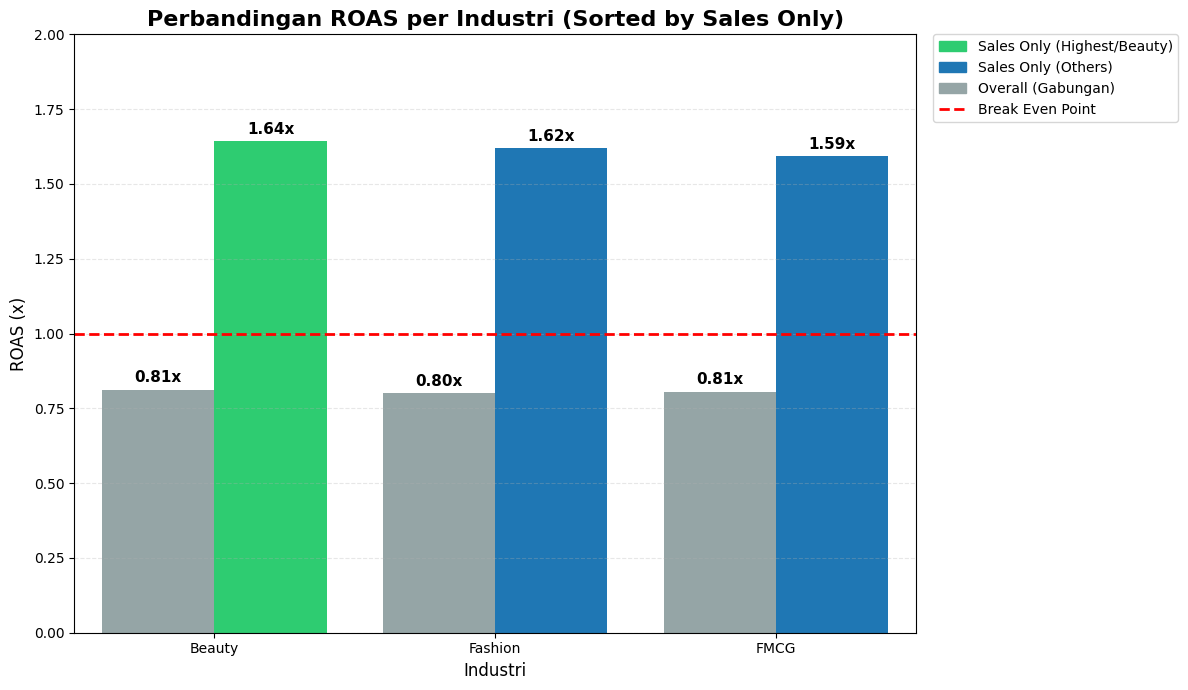

In [ ]:

import matplotlib.patches as mpatches

df = pd.read_csv('Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv')

df['purchase_value'] = pd.to_numeric(df['purchase_value'], errors='coerce').fillna(0)
df['amount_spent'] = pd.to_numeric(df['amount_spent'], errors='coerce').fillna(0)
df['Industry'] = df['account_name'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else 'Unknown')

overall = df.groupby('Industry').agg({'amount_spent':'sum', 'purchase_value':'sum'}).reset_index()
overall['ROAS'] = overall['purchase_value'] / overall['amount_spent']
overall['Metric'] = 'Overall (Gabungan)'

sales_only = df[df['campaign_objective'] == 'Sales'].groupby('Industry').agg({'amount_spent':'sum', 'purchase_value':'sum'}).reset_index()
sales_only['ROAS'] = sales_only['purchase_value'] / sales_only['amount_spent']
sales_only['Metric'] = 'Sales Only (Murni)'

sales_sorted = sales_only.sort_values('ROAS', ascending=False)
industry_order = sales_sorted['Industry'].tolist()

df_viz = pd.concat([overall, sales_only])

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=df_viz,
    x='Industry',
    y='ROAS',
    hue='Metric',
    order=industry_order
)

color_grey = '#95a5a6'
color_green = '#2ecc71'
color_blue = '#1f77b4'

for patch in ax.containers[0]:
    patch.set_facecolor(color_grey)

for i, patch in enumerate(ax.containers[1]):
    if i == 0:
        patch.set_facecolor(color_green)
    else:
        patch.set_facecolor(color_blue)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2fx', padding=3, fontsize=11, fontweight='bold')

plt.title('Perbandingan ROAS per Industri (Sorted by Sales Only)', fontsize=16, fontweight='bold')
plt.xlabel('Industri', fontsize=12)
plt.ylabel('ROAS (x)', fontsize=12)
plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Break Even Point (1.0x)')

legend_handles = [
    mpatches.Patch(color=color_green, label='Sales Only (Highest/Beauty)'),
    mpatches.Patch(color=color_blue, label='Sales Only (Others)'),
    mpatches.Patch(color=color_grey, label='Overall (Gabungan)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Break Even Point')
]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.ylim(0, 2.0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('roas_industry_comparison_custom_colors.png')
plt.show()

## Deep Analysis (The Bottleneck)

### Bottleneck

In [ ]:
import pandas as pd
import numpy as np

def safe_div(n, d):
    return np.where(d == 0, 0, n / d)

df_sales = data[data["campaign_objective"] == "Sales"].copy()

client_funnel = (
    df_sales
    .groupby("account_name")
    .agg({
        "impressions": "sum",
        "clicks": "sum",
        "link_clicks": "sum",
        "content_views": "sum",
        "add_to_cart": "sum",
        "purchase": "sum",
        "purchase_value": "sum",
        "amount_spent": "sum"
    })
    .reset_index()
)

client_funnel["CTR"] = safe_div(
    client_funnel["clicks"],
    client_funnel["impressions"]
)

client_funnel["LCR"] = safe_div(
    client_funnel["link_clicks"],
    client_funnel["clicks"]
)

client_funnel["CVR"] = safe_div(
    client_funnel["content_views"],
    client_funnel["link_clicks"]
)

client_funnel["ATC_rate"] = safe_div(
    client_funnel["add_to_cart"],
    client_funnel["content_views"]
)

client_funnel["Purchase_rate"] = safe_div(
    client_funnel["purchase"],
    client_funnel["content_views"]
)

client_funnel["ROAS"] = safe_div(
    client_funnel["purchase_value"],
    client_funnel["amount_spent"]
)

funnel_summary = (
    client_funnel[[
        "account_name",
        "CTR",
        "LCR",
        "CVR",
        "ATC_rate",
        "Purchase_rate",
        "ROAS",
        "purchase_value",
        "amount_spent"
    ]]
    .sort_values("ROAS", ascending=False)
)

funnel_summary["CTR"] = funnel_summary["CTR"] * 100
funnel_summary["LCR"] = funnel_summary["LCR"] * 100
funnel_summary["CVR"] = funnel_summary["CVR"] * 100
funnel_summary['ATC_rate'] = funnel_summary['ATC_rate'] * 100
funnel_summary['Purchase_rate'] = funnel_summary['Purchase_rate'] * 100

funnel_summary

,account_name,CTR,LCR,CVR,ATC_rate,Purchase_rate,ROAS,purchase_value,amount_spent
1,Client B,10.011643,48.158407,20.414155,10.150098,9.421177,1.671834,1.739974e+09,1.040758e+09
2,Client C,9.808589,51.178286,20.334436,10.163685,9.491763,1.671700,1.779702e+09,1.064607e+09
4,Client E,9.520748,53.628387,19.347498,10.276572,9.718992,1.634887,1.739546e+09,1.064016e+09
3,Client D,10.148881,47.173754,21.694849,10.082965,8.825103,1.616330,1.762483e+09,1.090423e+09
0,Client A,9.858449,51.222976,20.011732,9.870726,8.897495,1.568064,1.709628e+09,1.090279e+09
5,Client F,9.936043,48.431196,20.638344,9.939295,8.692426,1.552612,1.718880e+09,1.107089e+09


In [ ]:
import pandas as pd
import numpy as np

def safe_div(n, d):
    return np.where(d == 0, 0, n / d)

df_traffic = df[df["campaign_objective"] == "Traffic"].copy()

client_funnel = (
    df_traffic
    .groupby("account_name")
    .agg({
        "impressions": "sum",
        "clicks": "sum",
        "link_clicks": "sum",
        "reach": "sum",
        "amount_spent": "sum"
    })
    .reset_index()
)

client_funnel["CTR"] = safe_div(
    client_funnel["clicks"],
    client_funnel["impressions"]
) * 100

client_funnel["LCR"] = safe_div(
    client_funnel["link_clicks"],
    client_funnel["clicks"]
) * 100
client_funnel["Frequency"] = safe_div(
    client_funnel["reach"],
    client_funnel["impressions"]
)

funnel_summary = client_funnel[["account_name","Frequency", "CTR", "LCR"]]
print(funnel_summary)

         account_name  Frequency        CTR        LCR
0  Client A - Fashion   0.484404   9.790920  47.531481
1   Client B - Beauty   0.489212   9.806772  52.678229
2  Client C - Fashion   0.465658   9.591651  52.602659
3   Client D - Beauty   0.505737  10.571326  50.213696
4     Client E - FMCG   0.489813  10.215052  48.970735
5     Client F - FMCG   0.485209   9.971943  47.666004


### ALASAN ROAS TINGGI

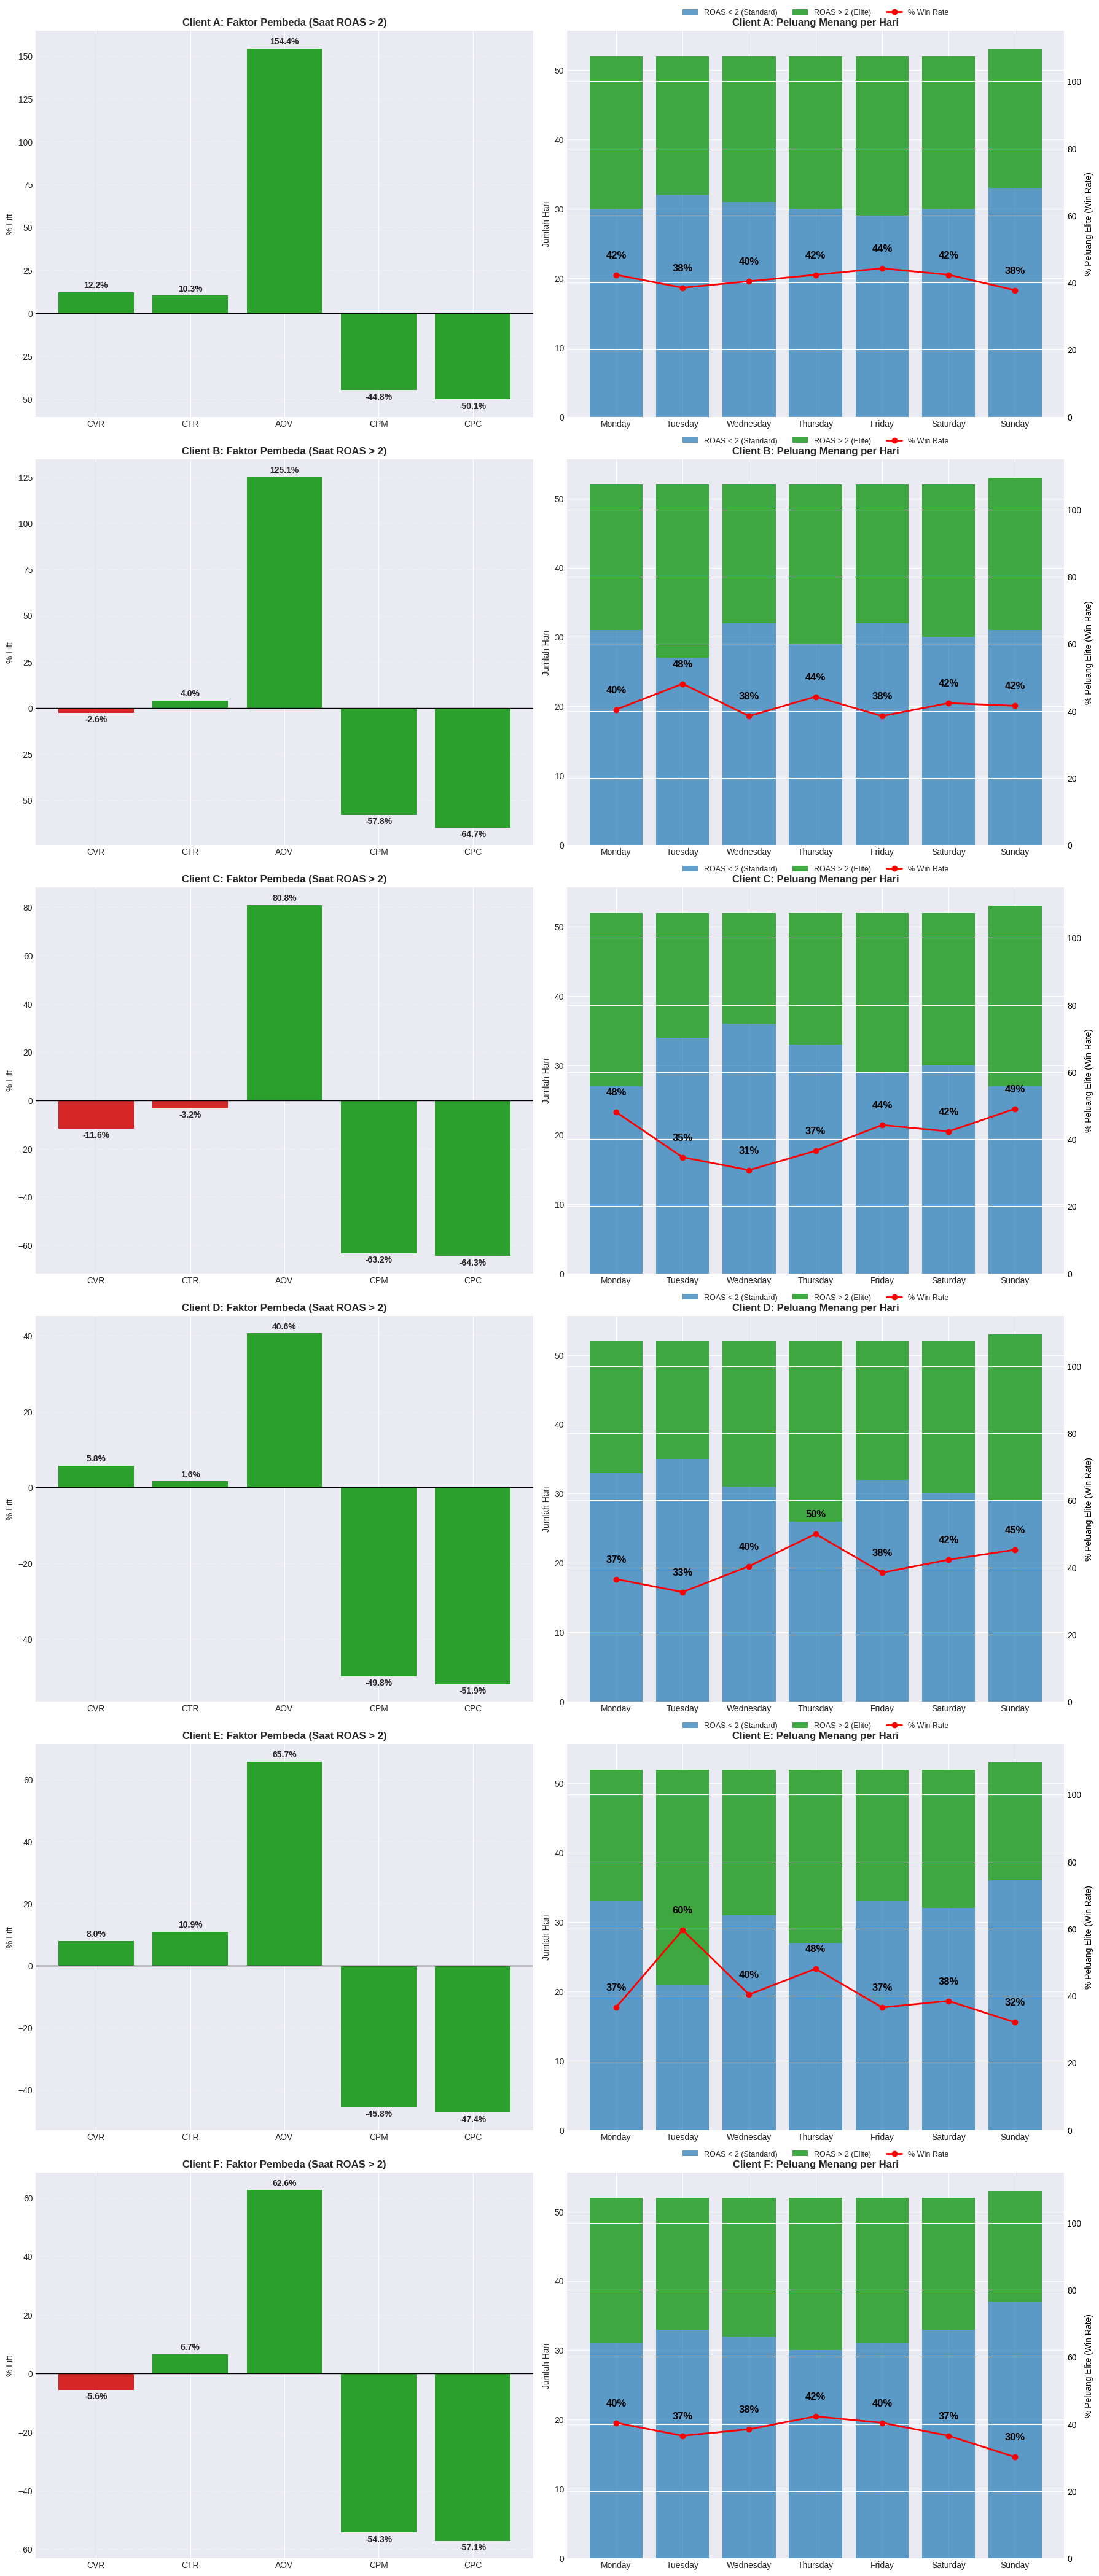

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)

df['created_date'] = pd.to_datetime(df['created_date'])
df['account_clean'] = df['account_name'].apply(lambda x: x.split(' - ')[0] if ' - ' in x else x)

numeric_cols = ['amount_spent', 'impressions', 'link_clicks', 'purchase', 'purchase_value']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df_sales = df[df['campaign_objective'] == 'Sales'].copy()

daily_acc = df_sales.groupby(['created_date', 'account_clean']).sum().reset_index()

daily_acc['ROAS'] = daily_acc['purchase_value'] / daily_acc['amount_spent']
daily_acc['CPM'] = (daily_acc['amount_spent'] / daily_acc['impressions']) * 1000
daily_acc['CTR'] = (daily_acc['link_clicks'] / daily_acc['impressions']) * 100
daily_acc['CVR'] = (daily_acc['purchase'] / daily_acc['link_clicks']) * 100
daily_acc['AOV'] = daily_acc['purchase_value'] / daily_acc['purchase']
daily_acc['CPC'] = daily_acc['amount_spent'] / daily_acc['link_clicks']

daily_acc['Day'] = daily_acc['created_date'].dt.day_name()
daily_acc = daily_acc.replace([float('inf'), -float('inf')], float('nan')).dropna()

daily_acc['Group'] = np.where(daily_acc['ROAS'] > 2.0, 'Elite (> 2.0)', 'Standard (< 2.0)')

unique_accounts = daily_acc['account_clean'].unique()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

n_acc = len(unique_accounts)
fig, axes = plt.subplots(n_acc, 2, figsize=(18, 7 * n_acc)) # Height ditambah sedikit biar lega
plt.subplots_adjust(hspace=0.6, wspace=0.3)

if n_acc == 1: axes = [axes]

for i, acc in enumerate(unique_accounts):
    acc_data = daily_acc[daily_acc['account_clean'] == acc]

    metrics_to_plot = ['CVR', 'CTR', 'AOV', 'CPM', 'CPC']
    comp = acc_data.groupby('Group')[metrics_to_plot].mean()

    diff_vals = []
    if 'Elite (> 2.0)' in comp.index and 'Standard (< 2.0)' in comp.index:
        elite = comp.loc['Elite (> 2.0)']
        std = comp.loc['Standard (< 2.0)']
        diff_vals = [
            ((elite['CVR'] - std['CVR']) / std['CVR']) * 100,
            ((elite['CTR'] - std['CTR']) / std['CTR']) * 100,
            ((elite['AOV'] - std['AOV']) / std['AOV']) * 100,
            ((elite['CPM'] - std['CPM']) / std['CPM']) * 100,
            ((elite['CPC'] - std['CPC']) / std['CPC']) * 100
        ]
    else:
        diff_vals = [0, 0, 0, 0, 0]

    ax1 = axes[i][0]
    bar_colors = []
    for m, val in zip(metrics_to_plot, diff_vals):
        if m in ['CPM', 'CPC']:
            bar_colors.append('#2ca02c' if val < 0 else '#d62728')
        else:
            bar_colors.append('#2ca02c' if val > 0 else '#d62728')

    bars = ax1.bar(metrics_to_plot, diff_vals, color=bar_colors)
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_title(f'{acc}: Faktor Pembeda (Saat ROAS > 2)', fontweight='bold', fontsize=12)
    ax1.set_ylabel('% Lift', fontsize=10)
    ax1.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    ct = pd.crosstab(acc_data['Day'], acc_data['Group']).reindex(day_order).fillna(0)

    if 'Standard (< 2.0)' not in ct.columns: ct['Standard (< 2.0)'] = 0
    if 'Elite (> 2.0)' not in ct.columns: ct['Elite (> 2.0)'] = 0

    ct['Total'] = ct['Standard (< 2.0)'] + ct['Elite (> 2.0)']
    ct['Win Rate'] = np.where(ct['Total'] > 0, (ct['Elite (> 2.0)'] / ct['Total']) * 100, 0)

    ax2 = axes[i][1]
    p1 = ax2.bar(ct.index, ct['Standard (< 2.0)'], label='ROAS < 2 (Standard)', color='#1f77b4', alpha=0.7)
    p2 = ax2.bar(ct.index, ct['Elite (> 2.0)'], bottom=ct['Standard (< 2.0)'], label='ROAS > 2 (Elite)', color='#2ca02c', alpha=0.9)

    ax2.set_ylabel('Jumlah Hari', fontsize=10)
    ax2.set_title(f'{acc}: Peluang Menang per Hari', fontweight='bold', fontsize=12)


    ax2_twin = ax2.twinx()
    line = ax2_twin.plot(ct.index, ct['Win Rate'], color='red', marker='o', linewidth=2, linestyle='-', label='% Win Rate')

    ax2_twin.set_ylabel('% Peluang Elite (Win Rate)', color='black', fontsize=10)
    ax2_twin.tick_params(axis='y', labelcolor='black')
    ax2_twin.set_ylim(0, 115)

    for x_idx, rate in enumerate(ct['Win Rate']):
        if ct['Total'].iloc[x_idx] > 0: # Hanya label jika ada data
            ax2_twin.text(x_idx, rate + 5, f'{rate:.0f}%', color='black', ha='center', fontsize=12, fontweight='bold')

    lines_1, labels_1 = ax2.get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()

    ax2.legend(lines_1 + lines_2, labels_1 + labels_2,
               loc='lower center', bbox_to_anchor=(0.5, 1.02),
               ncol=3, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('loop_analysis_final_fixed_legend.png')
plt.show()

### CARI CPM TERMURAH

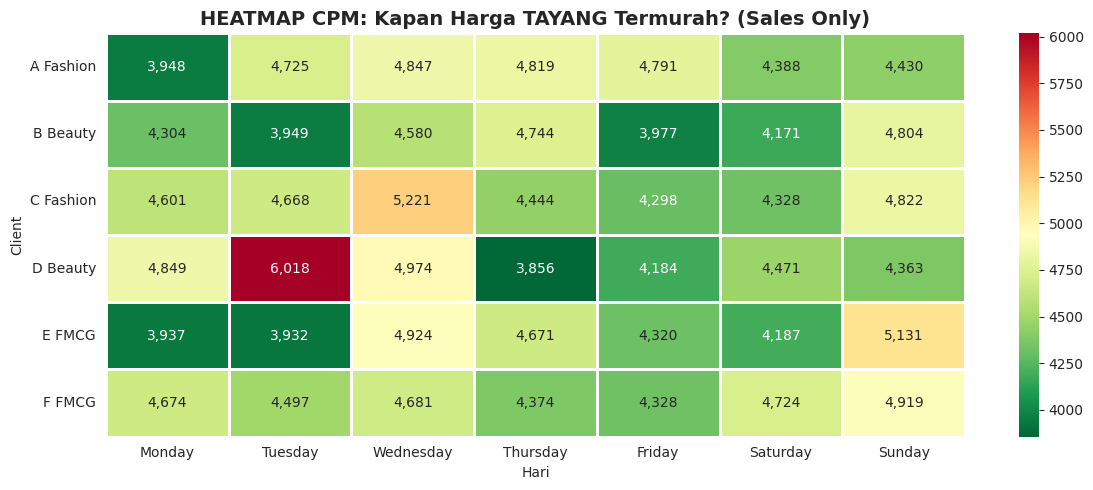

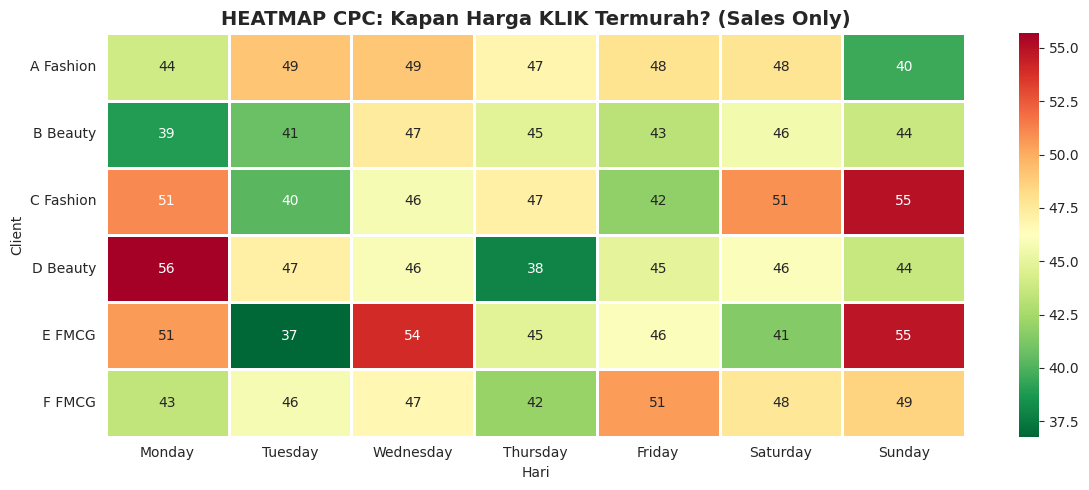

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)

df['created_date'] = pd.to_datetime(df['created_date'])

df_sales = df[df['campaign_objective'] == 'Sales'].copy()

def clean_client_name(name):
    return name.replace('Client ', '').replace(' - ', ' ')

df_sales['client_label'] = df_sales['account_name'].apply(clean_client_name)
df_sales['day_name'] = df_sales['created_date'].dt.day_name()

daily_metrics = df_sales.groupby(['client_label', 'day_name'])[['amount_spent', 'impressions', 'clicks']].sum().reset_index()

daily_metrics['CPM'] = (daily_metrics['amount_spent'] / daily_metrics['impressions']) * 1000
daily_metrics['CPC'] = daily_metrics.apply(
    lambda x: x['amount_spent'] / x['clicks'] if x['clicks'] > 0 else 0, axis=1
)

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

cpm_pivot = daily_metrics.pivot(index='client_label', columns='day_name', values='CPM')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cpm_pivot = cpm_pivot.reindex(columns=days_order)

plt.figure(figsize=(12, 5), facecolor='white')
sns.heatmap(cpm_pivot, annot=True, fmt=",.0f", cmap='RdYlGn_r', linewidths=1)
plt.title('HEATMAP CPM: Kapan Harga TAYANG Termurah? (Sales Only)', fontsize=14, fontweight='bold')
plt.ylabel('Client')
plt.xlabel('Hari')
plt.tight_layout()
plt.savefig('heatmap_cpm_white.png')
plt.show()

cpc_pivot = daily_metrics.pivot(index='client_label', columns='day_name', values='CPC')
cpc_pivot = cpc_pivot.reindex(columns=days_order)

plt.figure(figsize=(12, 5), facecolor='white')
sns.heatmap(cpc_pivot, annot=True, fmt=",.0f", cmap='RdYlGn_r', linewidths=1)
plt.title('HEATMAP CPC: Kapan Harga KLIK Termurah? (Sales Only)', fontsize=14, fontweight='bold')
plt.ylabel('Client')
plt.xlabel('Hari')
plt.tight_layout()
plt.savefig('heatmap_cpc_white.png')
plt.show()

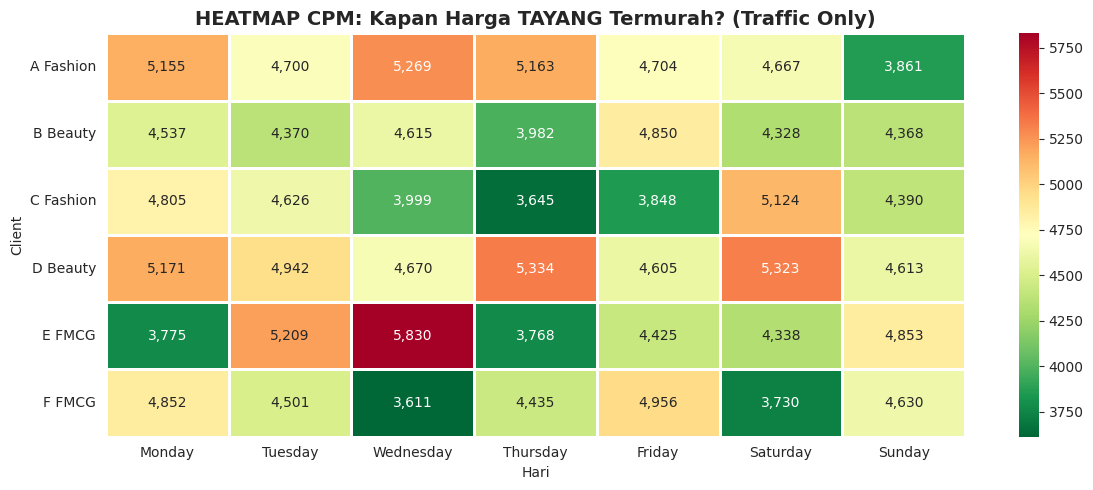

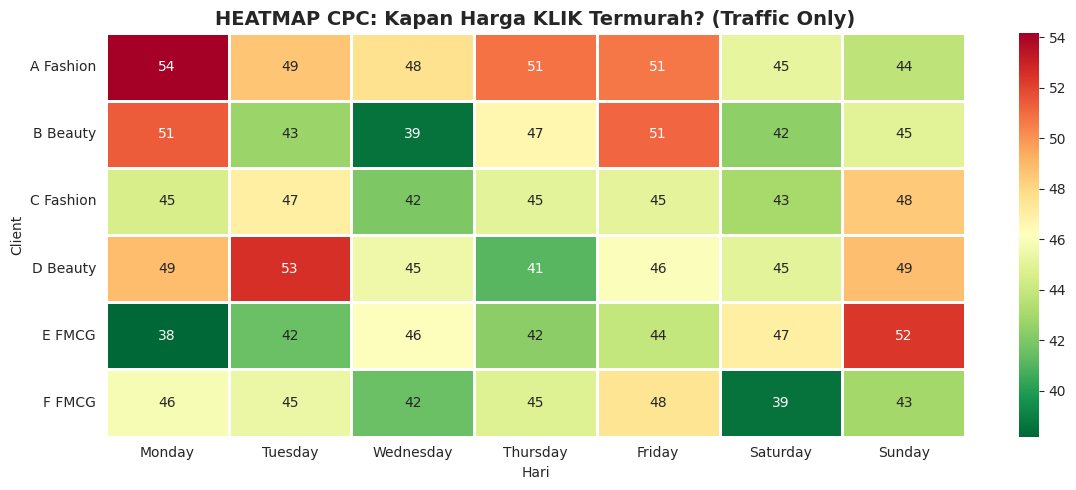

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)

df['created_date'] = pd.to_datetime(df['created_date'])

df_Traffic = df[df['campaign_objective'] == 'Traffic'].copy()

def clean_client_name(name):
    return name.replace('Client ', '').replace(' - ', ' ')

df_Traffic['client_label'] = df_Traffic['account_name'].apply(clean_client_name)
df_Traffic['day_name'] = df_Traffic['created_date'].dt.day_name()

daily_metrics = df_Traffic.groupby(['client_label', 'day_name'])[['amount_spent', 'impressions', 'clicks']].sum().reset_index()

daily_metrics['CPM'] = (daily_metrics['amount_spent'] / daily_metrics['impressions']) * 1000
daily_metrics['CPC'] = daily_metrics.apply(
    lambda x: x['amount_spent'] / x['clicks'] if x['clicks'] > 0 else 0, axis=1
)

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

cpm_pivot = daily_metrics.pivot(index='client_label', columns='day_name', values='CPM')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cpm_pivot = cpm_pivot.reindex(columns=days_order)

plt.figure(figsize=(12, 5), facecolor='white')
sns.heatmap(cpm_pivot, annot=True, fmt=",.0f", cmap='RdYlGn_r', linewidths=1)
plt.title('HEATMAP CPM: Kapan Harga TAYANG Termurah? (Traffic Only)', fontsize=14, fontweight='bold')
plt.ylabel('Client')
plt.xlabel('Hari')
plt.tight_layout()
plt.savefig('heatmap_cpm_white.png')
plt.show()

cpc_pivot = daily_metrics.pivot(index='client_label', columns='day_name', values='CPC')
cpc_pivot = cpc_pivot.reindex(columns=days_order)

plt.figure(figsize=(12, 5), facecolor='white')
sns.heatmap(cpc_pivot, annot=True, fmt=",.0f", cmap='RdYlGn_r', linewidths=1)
plt.title('HEATMAP CPC: Kapan Harga KLIK Termurah? (Traffic Only)', fontsize=14, fontweight='bold')
plt.ylabel('Client')
plt.xlabel('Hari')
plt.tight_layout()
plt.savefig('heatmap_cpc_white.png')
plt.show()

### PERBANDINGAN CPC dan CPM

/tmp/ipython-input-1783767663.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comp, x='campaign_objective', y='CPM', palette=my_pal, ax=axes[0], showfliers=False, width=0.5)
/tmp/ipython-input-1783767663.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comp, x='campaign_objective', y='CPC', palette=my_pal, ax=axes[1], showfliers=False, width=0.5)


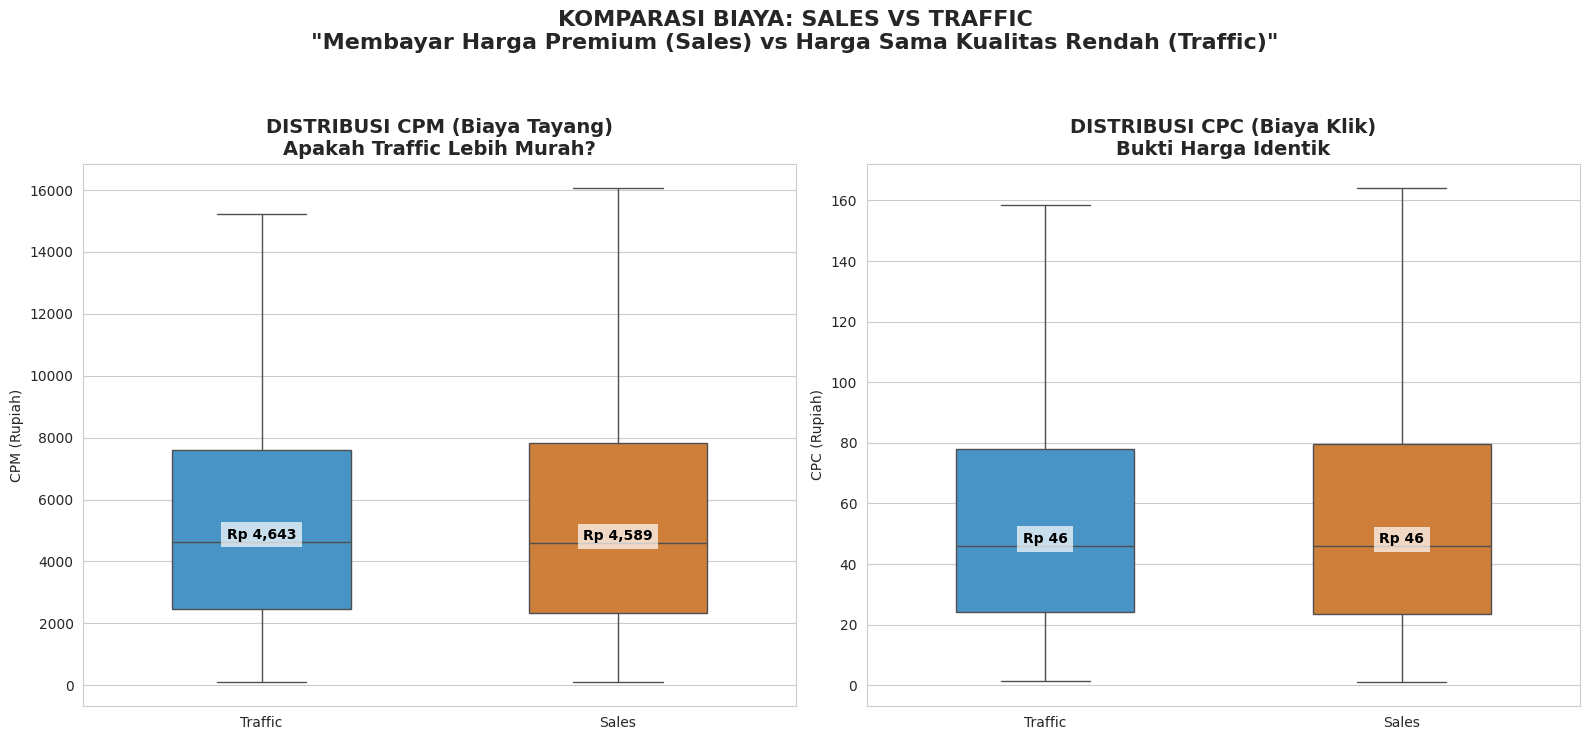

--- MEDIAN HARGA (TENGAH) ---
                            CPM        CPC
campaign_objective                        
Sales               4589.301792  45.830463
Traffic             4642.575601  45.987968


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)

numeric_cols = ['amount_spent', 'impressions', 'clicks']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df_comp = df[df['campaign_objective'].isin(['Traffic', 'Sales'])].copy()

df_comp['CPM'] = (df_comp['amount_spent'] / df_comp['impressions']) * 1000


df_comp['CPC'] = df_comp.apply(lambda x: x['amount_spent'] / x['clicks'] if x['clicks'] > 0 else np.nan, axis=1)

df_comp = df_comp.dropna(subset=['CPM', 'CPC'])
df_comp = df_comp[df_comp['CPM'] < 100000]

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
my_pal = {'Traffic': '#3498db', 'Sales': '#e67e22'}

def add_median_labels(ax):
    lines = ax.get_lines()
    medians = [line.get_ydata()[0] for line in lines[4::5]]
    x_positions = ax.get_xticks()

    for x, y in zip(x_positions, medians):
        ax.text(x, y, f'Rp {y:,.0f}',
                horizontalalignment='center',
                verticalalignment='bottom',
                fontweight='bold',
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

sns.boxplot(data=df_comp, x='campaign_objective', y='CPM', palette=my_pal, ax=axes[0], showfliers=False, width=0.5)
axes[0].set_title('DISTRIBUSI CPM (Biaya Tayang)\nApakah Traffic Lebih Murah?', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CPM (Rupiah)')
axes[0].set_xlabel('')
add_median_labels(axes[0])


sns.boxplot(data=df_comp, x='campaign_objective', y='CPC', palette=my_pal, ax=axes[1], showfliers=False, width=0.5)
axes[1].set_title('DISTRIBUSI CPC (Biaya Klik)\nBukti Harga Identik', fontsize=14, fontweight='bold')
axes[1].set_ylabel('CPC (Rupiah)')
axes[1].set_xlabel('')
add_median_labels(axes[1])

plt.suptitle('KOMPARASI BIAYA: SALES VS TRAFFIC\n"Membayar Harga Premium (Sales) vs Harga Sama Kualitas Rendah (Traffic)"',
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('boxplot_clean_comparison.png', bbox_inches='tight')
plt.show()

# Print Data Median untuk Validasi Narasi
print("--- MEDIAN HARGA (TENGAH) ---")
print(df_comp.groupby('campaign_objective')[['CPM', 'CPC']].median())

### AOV tertinggi

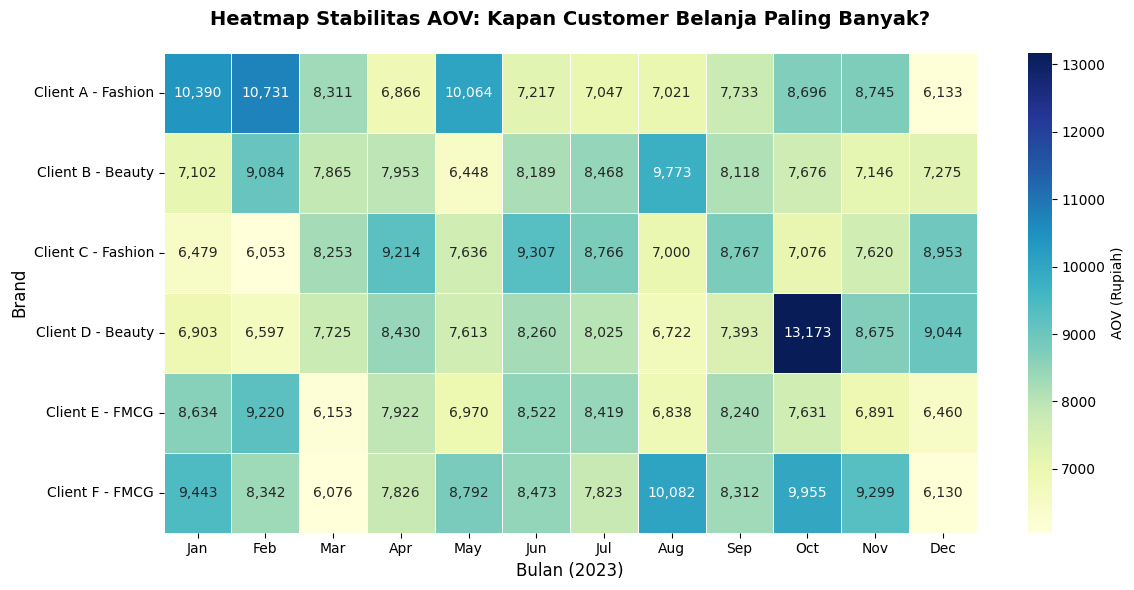

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
    df = pd.read_csv(filename)

    df['created_date'] = pd.to_datetime(df['created_date'])
    cols = ['purchase', 'purchase_value']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df_sales = df[df['campaign_objective'] == 'Sales'].copy()

    df_monthly = df_sales.groupby([
        'account_name',
        df_sales['created_date'].dt.to_period('M')
    ])[cols].sum().reset_index()

    df_monthly['AOV'] = df_monthly.apply(
        lambda x: (x['purchase_value'] / x['purchase']) if x['purchase'] > 0 else 0, axis=1
    )

    df_monthly['Month_Num'] = df_monthly['created_date'].dt.month
    df_monthly['Month_Name'] = df_monthly['created_date'].dt.strftime('%b')
    heatmap_data = df_monthly.pivot(index='account_name', columns='Month_Num', values='AOV')
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    heatmap_data.columns = [month_map[c] for c in heatmap_data.columns]
    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'AOV (Rupiah)'})

    plt.title('Heatmap Stabilitas AOV: Kapan Customer Belanja Paling Banyak?', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Bulan (2023)', fontsize=12)
    plt.ylabel('Brand', fontsize=12)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('heatmap_aov.png')
    plt.show()

except Exception as e:
    print(f"Error: {e}")

3## Scalability Analysis

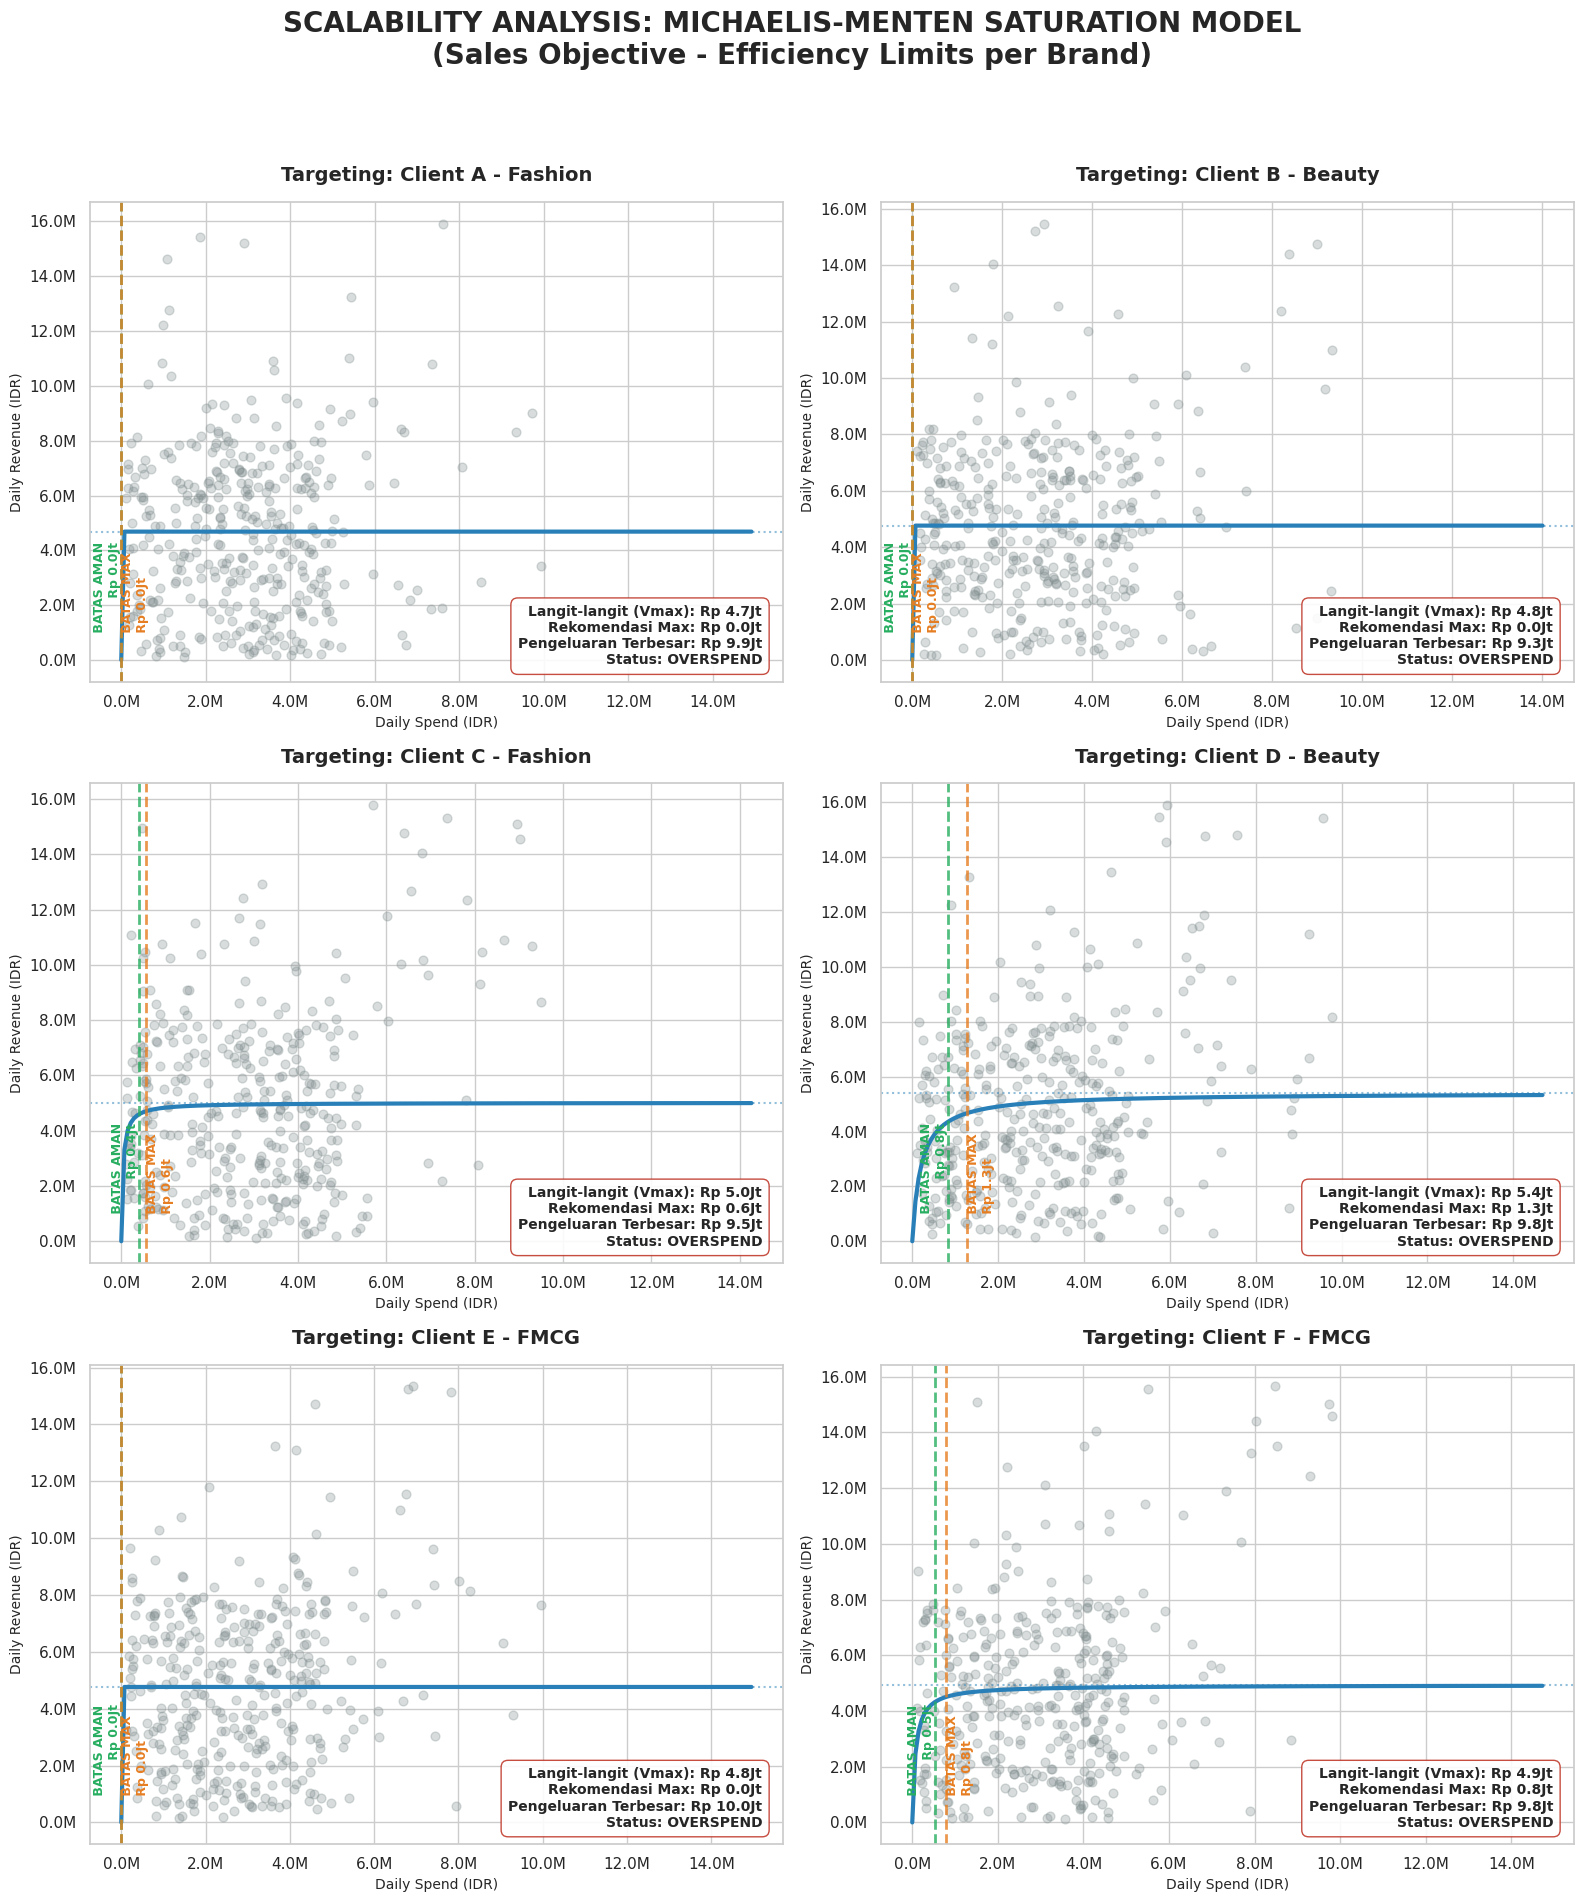


RINGKASAN REKOMENDASI BUDGET SALES PER BRAND
| Brand              |   Vmax (Jt) |   Batas Aman (Jt) |   Batas Max (Jt) |   Max Actual (Jt) | Status    |
|:-------------------|------------:|------------------:|-----------------:|------------------:|:----------|
| Client A - Fashion |         4.7 |               0   |              0   |               9.9 | OVERSPEND |
| Client B - Beauty  |         4.8 |               0   |              0   |               9.3 | OVERSPEND |
| Client C - Fashion |         5   |               0.4 |              0.6 |               9.5 | OVERSPEND |
| Client D - Beauty  |         5.4 |               0.8 |              1.3 |               9.8 | OVERSPEND |
| Client E - FMCG    |         4.8 |               0   |              0   |              10   | OVERSPEND |
| Client F - FMCG    |         4.9 |               0.5 |              0.8 |               9.8 | OVERSPEND |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

sns.set_theme(style="whitegrid")
filename = "Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv"
df = pd.read_csv(filename)

df['created_date'] = pd.to_datetime(df['created_date'])
cols = ['amount_spent', 'purchase_value']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_sales = df[df['campaign_objective'] == 'Sales'].copy()

def saturation_model(x, vmax, km):
    return (vmax * x) / (km + x)

def get_spend_at_marginal_roas(target_roas, vmax, km):
    try:
        if vmax * km == 0: return 0
        spend = np.sqrt((vmax * km) / target_roas) - km
        return max(0, spend)
    except:
        return 0
brands = sorted(df_sales['account_name'].unique())
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()
summary_results = []

for i, brand in enumerate(brands):
    ax = axes[i]
    brand_data = df_sales[df_sales['account_name'] == brand].groupby('created_date')[cols].sum().reset_index()
    brand_data = brand_data[brand_data['amount_spent'] > 1000]

    x = brand_data['amount_spent']
    y = brand_data['purchase_value']

    if len(x) < 5:
        ax.text(0.5, 0.5, 'Data Tidak Cukup', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(brand)
        continue

    # Fit Model
    p0_guess = [y.max() * 1.5, x.median()]
    try:
        popt, _ = curve_fit(saturation_model, x, y, p0=p0_guess, bounds=(0, np.inf), maxfev=10000)
        vmax, km = popt
    except:
        vmax, km = 0, 0

    safe_spend = get_spend_at_marginal_roas(1.0, vmax, km)
    max_profit_spend = get_spend_at_marginal_roas(0.5, vmax, km)
    max_actual_spend = x.max()

    ax.scatter(x, y, alpha=0.3, color='#7f8c8d', s=40, label='Data Harian')

    if vmax > 0:
        x_max_plot = max(x.max() * 1.5, max_profit_spend * 1.2)
        x_line = np.linspace(0, x_max_plot, 200)
        y_line = saturation_model(x_line, vmax, km)
        ax.plot(x_line, y_line, color='#2980b9', linewidth=3, label='Kurva Saturasi')

        ax.axhline(vmax, color='#2980b9', linestyle=':', alpha=0.5)

        y_limit = ax.get_ylim()[1]

        if safe_spend > 0:
            ax.axvline(safe_spend, color='#27ae60', linestyle='--', linewidth=2, alpha=0.8)
            ax.text(safe_spend, y_limit * 0.05, f' BATAS AMAN\n Rp {safe_spend/1e6:.1f}Jt',
                    color='#27ae60', fontweight='bold', fontsize=9, rotation=90, va='bottom', ha='right')

        if max_profit_spend > 0:
            ax.axvline(max_profit_spend, color='#e67e22', linestyle='--', linewidth=2, alpha=0.8)
            ax.text(max_profit_spend, y_limit * 0.05, f' BATAS MAX\n Rp {max_profit_spend/1e6:.1f}Jt',
                    color='#e67e22', fontweight='bold', fontsize=9, rotation=90, va='bottom', ha='left')

        status = "OVERSPEND" if max_actual_spend > max_profit_spend else "OPTIMAL"
        status_color = "#c0392b" if status == "OVERSPEND" else "#27ae60"

        text_str = (f"Langit-langit (Vmax): Rp {vmax/1e6:.1f}Jt\n"
                    f"Rekomendasi Max: Rp {max_profit_spend/1e6:.1f}Jt\n"
                    f"Pengeluaran Terbesar: Rp {max_actual_spend/1e6:.1f}Jt\n"
                    f"Status: {status}")

        ax.text(0.97, 0.03, text_str, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right',
                fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor=status_color))

        summary_results.append({
            'Brand': brand,
            'Vmax (Jt)': f"{vmax/1e6:.1f}",
            'Batas Aman (Jt)': f"{safe_spend/1e6:.1f}",
            'Batas Max (Jt)': f"{max_profit_spend/1e6:.1f}",
            'Max Actual (Jt)': f"{max_actual_spend/1e6:.1f}",
            'Status': status
        })

    ax.set_title(f"Targeting: {brand}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Daily Spend (IDR)', fontsize=10)
    ax.set_ylabel('Daily Revenue (IDR)', fontsize=10)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.suptitle('SCALABILITY ANALYSIS: MICHAELIS-MENTEN SATURATION MODEL\n(Sales Objective - Efficiency Limits per Brand)',
             fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('clean_saturation_analysis_per_brand.png', dpi=100)
plt.show()

if summary_results:
    df_res = pd.DataFrame(summary_results)
    print("\n" + "="*85)
    print("RINGKASAN REKOMENDASI BUDGET SALES PER BRAND")
    print("="*85)
    print(df_res.to_markdown(index=False))
    print("="*85)

### Simulasi Perbaikan Jika DIlakukan

Text(145.72222222222223, 0.5, 'CVR (Content View Rate)')

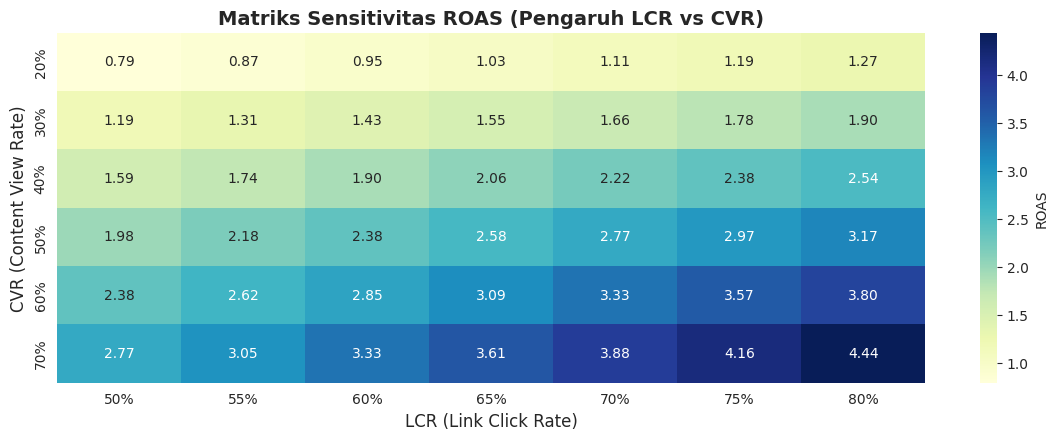

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Data Ads - Kompetisi Data Analyts by inSight Data Batch 01.csv')

traffic_spend = df[df['campaign_objective'] == 'Traffic']['amount_spent'].sum()
sales_spend = df[df['campaign_objective'] == 'Sales']['amount_spent'].sum()
total_spend = traffic_spend + sales_spend

sales_data = df[df['campaign_objective'] == 'Sales'].sum(numeric_only=True)
sales_clicks = sales_data['clicks']
sales_atc = sales_data['add_to_cart']
sales_cv = sales_data['content_views']
sales_purchase = sales_data['purchase']
sales_rev = sales_data['purchase_value']

actual_lcr = (sales_data['link_clicks'] / sales_clicks)
actual_cv_rate = (sales_cv / sales_data['link_clicks'])
atc_per_cv = sales_atc / sales_cv
pur_per_atc = sales_purchase / sales_atc
aov = sales_rev / sales_purchase

def calculate_roas(lcr, cvr):
    sim_link_clicks = sales_clicks * lcr
    sim_cv = sim_link_clicks * cvr
    sim_atc = sim_cv * atc_per_cv
    sim_purchase = sim_atc * pur_per_atc
    sim_revenue = sim_purchase * aov
    return sim_revenue / total_spend

lcr_range = np.linspace(0.50, 0.80, 7)
cvr_range = np.linspace(0.20, 0.70, 6)

heatmap_data = pd.DataFrame(index=[f"{int(c*100)}%" for c in cvr_range],
                            columns=[f"{int(l*100)}%" for l in lcr_range])

for l in lcr_range:
    for c in cvr_range:
        roas = calculate_roas(l, c)
        heatmap_data.loc[f"{int(c*100)}%", f"{int(l*100)}%"] = roas

heatmap_data = heatmap_data.astype(float)

scenarios = {
    'Saat Ini (Actual)': (actual_lcr, actual_cv_rate),
    'Creative Fix (LCR 70%)': (0.70, actual_cv_rate),
    'Web Fix (CVR 40%)': (actual_lcr, 0.40),
    'Balanced (LCR 60%, CVR 40%)': (0.60, 0.40),
    'Excellent (LCR 70%, CVR 60%)': (0.70, 0.60)
}

scenario_results = []
for name, (l, c) in scenarios.items():
    roas = calculate_roas(l, c)
    scenario_results.append({'Scenario': name, 'LCR': f"{l*100:.1f}%", 'CVR': f"{c*100:.1f}%", 'ROAS': round(roas, 2)})

scenario_df = pd.DataFrame(scenario_results)

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'ROAS'})
plt.title('Matriks Sensitivitas ROAS (Pengaruh LCR vs CVR)', fontsize=14, fontweight='bold')
plt.xlabel('LCR (Link Click Rate)', fontsize=12)
plt.ylabel('CVR (Content View Rate)', fontsize=12)